In [ ]:
# Load Data
import pandas as pd
quotation_data_path = r"C:\Users\Phong\OneDrive - ICB Construction\Phong\data\Python_ETL\DS\ML_Models\data\Quotation Data.xlsx"
quotation_data_df = pd.read_excel(quotation_data_path)

In [ ]:
# Custom Date Feature Engineering
# Label missing Date, fill missing Date with median
# Extract Year, Quarter, Month, DayOfWeek and trasform them to cyclical sin and cos
# ================================================================
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

class DateFeatureTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, date_column="Date"):
        self.date_column = date_column

    # fit method is only ever called on your training dataset, it learns the median.
    def fit(self, X, y=None):
        dates = pd.to_datetime(
            X[self.date_column],
            errors="coerce"
        )
        self.median_date_ = dates.dropna().median()
        return self
    
    # transform method is called on your training data and later on your hidden test data, it uses the learned median.
    def transform(self, X):
        X = X.copy()
        X[self.date_column] = pd.to_datetime(
            X[self.date_column],
            errors="coerce"
        )

        # Missing Indicator
        X["DateMissing"] = X[self.date_column].isna().astype(int)

        # Median Imputation
        X[self.date_column] = X[self.date_column].fillna(
            self.median_date_
        )

        # Date Features
        X["Date_Year"] = X[self.date_column].dt.year
        X["Date_Quarter"] = X[self.date_column].dt.quarter

        month = X[self.date_column].dt.month
        dow = X[self.date_column].dt.dayofweek

        X["month_sin"] = np.sin(2*np.pi*month/12)
        X["month_cos"] = np.cos(2*np.pi*month/12)

        X["dayofweek_sin"] = np.sin(2*np.pi*dow/7)
        X["dayofweek_cos"] = np.cos(2*np.pi*dow/7)

        X.drop(columns=self.date_column, inplace=True)
        return X

In [ ]:
# Numeric Feature Engineering
# Transform numeric feature using log to reduce skewness for Classification
# ================================================================
class NumericFeatureTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        # Reduce skewness
        X["Value"] = np.log1p(X["Value"])
        return X

In [ ]:
# Estimator Feature Engineering
# Split the values in the feature and create new columns based on that
# ================================================================
class EstimatorFeatureTransformer(BaseEstimator, TransformerMixin):

    def __init__(self, column="Priced_By"):
        self.column = column

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # Number of estimators
        X["EstimatorCount"] = (
            X[self.column]
            .str.split("/")
            .apply(len)
        )

        # If the value is "MISSING", treat it as 0 estimators
        X.loc[
            X[self.column].str.upper() == "MISSING",
            "EstimatorCount"
        ] = 0

        X["EstimatorCount"] = X["EstimatorCount"].astype(int)

        # Multiple estimator flag
        X["MultipleEstimators"] = (
            X["EstimatorCount"] > 1
        ).astype(int)

        # Missing Estimator flag
        X["EstimatorMissing"] = (
            X[self.column]
            .str.upper()
            .eq("MISSING")
        ).astype(int)

        return X

In [ ]:
# RareGrouper 
# ================================================================
class RareCategoryGrouper(BaseEstimator, TransformerMixin):
    def __init__(self, columns, min_frequency=10):
        self.columns = columns
        self.min_frequency = min_frequency
    
    def fit(self, X, y=None):
        X = X.copy()

        self.frequent_categories_ = {}

        for col in self.columns:

            counts = X[col].value_counts(dropna=False)

            self.frequent_categories_[col] = set(
                counts[counts >= self.min_frequency].index
            )

        return self
    
    def transform(self, X):
        X = X.copy()

        for col in self.columns:
            X[col] = np.where(
                X[col].isin(self.frequent_categories_[col]),
                X[col],
                "other"
            )

        return X
    
# Inspect the frequency distribution to determine the threshold for min frequency
client_counts = quotation_data_df["Client_Clean"].value_counts()

print(client_counts.describe())

print(client_counts.head(20))
print(client_counts.tail(20))

# Check how many grouper left with different min_frequency threshold
for threshold in [2, 5, 10, 20, 30, 50]:
    kept = (client_counts >= threshold).sum()
    print(f"{threshold:2d}: keep {kept:3d} clients")


In [ ]:
# Save dataframe after trasformation for checking
# ================================================================
from sklearn.pipeline import Pipeline

# 1. Build a preprocessing-only pipeline using your existing objects
debug_pipeline = Pipeline([
    ("date_features", DateFeatureTransformer()),
    ("rare_grouper", RareCategoryGrouper(
        columns=["Client_Clean", "Suburb"],
        min_frequency=20
    )),
    ("numeric_features", NumericFeatureTransformer()),
    ("preprocessor", preprocessor)
])

# 2. Fit and transform your training data to see the final numeric matrix
X_train_transformed = debug_pipeline.fit_transform(X_train)

# 3. Retrieve the post-one-hot-encoded column names from the preprocessor step
# Note: This requires scikit-learn 1.0 or newer
feature_names = debug_pipeline.named_steps["preprocessor"].get_feature_names_out()

# 4. Reconstruct into a beautiful, readable DataFrame
transformed_df = pd.DataFrame(X_train_transformed, columns=feature_names, index=X_train.index)

# 5. Export locally to a CSV file
transformed_df.to_csv(r"C:\Users\Phong\Downloads\Quotation Data Test.csv", index=False)

print(f"✅ Success! Exported a matrix of {transformed_df.shape[0]} rows and {transformed_df.shape[1]} columns.")
print("Check your local directory for 'transformed_training_data.csv'.")

In [ ]:
# Save Trained Model and make prediction from local file - Classification
from joblib import dump

dump(lgr_best_model_v3, "LogisticRegression_V3.joblib")
print("Model saved.")

# Make Classification Prediction from data file
import pandas as pd
from joblib import load

# ==========================================
# Load trained model
# ==========================================
model = load("LogisticRegression_V3.joblib")

# ==========================================
# Load Excel file
# ==========================================
new_df = pd.read_excel(r"C:\Users\Phong\OneDrive - ICB Construction\Phong\data\Python_ETL\DS\ML_Models\data\Quotation Data Test.xlsx")

# ==========================================
# Keep only raw features
# ==========================================
raw_features = [
    "Date",
    "Value",
    "No_Wall_Types",
    "Priced_By",
    "Contact_Clean",
    "Suburb",
    "Client_Clean",
    "Timber_RW","RC_Pile","Steel_Beam","Sheetpile","Anchor","Block",
    "Shotcrete","Capping_Beam","Earthwork","Concrete_Slab","Precast",
    "Culvert","Slip_Repair","Soil_Nail","Rock_RW","Bridge","Concrete",
    "Design_and_Build","Budget","Drill_Only","Labour_Only",
    "Driven_Pile","Palisade","Boardwalk","Soldier","Insitu",
    "Barrier","Noise_RW","Base","Casing","Crib",
    "DayWork","Flood_Repair","Micro_Pile","Reno",
    "Temp_RW","Other"
]

X_new = new_df[raw_features]

# ==========================================
# Predict
# ==========================================
pred_class = model.predict(X_new)

pred_probability = model.predict_proba(X_new)

# Probability of Profit (class=1)
profit_probability = pred_probability[:,1]

loss_probability = pred_probability[:,0]

# ==========================================
# Save predictions
# ==========================================
new_df["Prediction"] = pred_class

new_df["Prediction_Label"] = new_df["Prediction"].map({
    0:"Lost",
    1:"Won"
})

new_df["Probability_Won"] = profit_probability

new_df["Probability_Lost"] = loss_probability

# ==========================================
# Save CSV
# ==========================================
output_file = r"C:\Users\Phong\Downloads\Quotation Prediction.csv"

new_df.to_csv(output_file, index=False)
print(f"Prediction saved to:\n{output_file}")

In [ ]:
# Analysis Data 01 - Grouping unique value of Feature 
# to calculate: "size" - total number for unique value of Feature in column "Success"
# to calculate: "mean" - average for unique value of Feature in column "Success" 
summary = (
    quotation_data_df
    .groupby("Priced_By")
    .agg(
        Quotes=("Success", "size"),
        WinRate=("Success", "mean")
    )
    .sort_values("Quotes", ascending=False)
)

print(summary)

In [ ]:
import json

cells = []

def md(text):
    cells.append({
        "cell_type": "markdown",
        "metadata": {},
        "source": text.splitlines(keepends=True)
    })

def code(text):
    cells.append({
        "cell_type": "code",
        "execution_count": None,
        "metadata": {},
        "outputs": [],
        "source": text.splitlines(keepends=True)
    })

# =================================================================
# TITLE
# =================================================================
md("""# Quotation Win/Loss Prediction — EDA + Logistic Regression Baseline

**Goal:** predict whether a construction quotation will be Won (`Success`=1) or Lost (`Success`=0), with an emphasis on explainability (coefficients, odds ratios, SHAP).

**This notebook covers:**
1. Load & inspect the data
2. EDA — missing values, target balance, leakage check, distributions, trends
3. Cleaning & feature engineering
4. Train/test split (time-based — rationale explained below)
5. Preprocessing pipeline
6. Baseline Logistic Regression
7. Light hyperparameter tuning
8. Explainability — coefficients, odds ratios, bootstrap significance, SHAP

**Next notebooks (once we agree on the choices below):** Decision Tree → Random Forest → XGBoost → LightGBM → CatBoost → Neural Network, all reusing the same cleaned dataset and time-based split for a fair comparison.

> ⚠️ Update `DATA_PATH` in the config cell below to point at your copy of `Quotation_Data.xlsx` before running.
""")

# =================================================================
# SETUP
# =================================================================
code("""# Optional: only needed once per environment. Safe to skip if already installed.
# statsmodels is intentionally NOT used here -- see the note in Part 7 for why.
%pip install shap -q
""")

code("""import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, average_precision_score, confusion_matrix,
                              classification_report, RocCurveDisplay, PrecisionRecallDisplay)

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
""")

md("## Configuration\nAll the knobs that shape the pipeline live here so you can tune them without hunting through the notebook.")

code("""DATA_PATH = '/mnt/user-data/uploads/Quotation_Data.xlsx'   # <-- update this to your local path

RANDOM_STATE = 42
TEST_FRACTION = 0.20        # last 20% of quotations by date held out as the test set
MIN_CATEGORY_COUNT = 15     # categories seen fewer times than this get grouped into "infrequent"
RARE_WALLTYPE_PCT = 1.0     # wall-type flags present in fewer than this % of rows get grouped

WALL_TYPE_COLS = ['Timber_RW','RC_Pile','Steel_Beam','Sheetpile','Anchor','Block','Shotcrete',
                  'Capping_Beam','Earthwork','Concrete_Slab','Precast','Culvert','Slip_Repair',
                  'Soil_Nail','Rock_RW','Bridge','Concrete','Design_and_Build','Budget','Drill_Only',
                  'Labour_Only','Driven_Pile','Palisade','Boardwalk','Soldier','Insitu','Barrier',
                  'Noise_RW','Base','Casing','Crib','DayWork','Flood_Repair','Micro_Pile','Reno',
                  'Temp_RW','Other']
""")

# =================================================================
# PART 1: LOAD & INSPECT
# =================================================================
md("## Part 1 — Load & Inspect")

code("""df_raw = pd.read_excel(DATA_PATH, sheet_name='Data')
print('Shape:', df_raw.shape)
df_raw.head()
""")

code("""info = pd.DataFrame({
    'dtype': df_raw.dtypes.astype(str),
    'n_missing (naive)': df_raw.isna().sum(),
    'pct_missing (naive)': (df_raw.isna().sum() / len(df_raw) * 100).round(1),
    'n_unique': df_raw.nunique(),
})
info
""")

md("""### ⚠️ Missing values are understated above

Several columns encode "missing" as a literal string (`"MISSING"`, `"Missing"`, `"na"`, `"unknown"`, blank spaces...) instead of a real `NaN`. Pandas' `.isna()` doesn't catch these, so the table above significantly *understates* real missingness for some columns. The next cell scans every text column for these sentinel tokens and converts them to proper `NaN` before we do anything else.""")

code("""SENTINELS = {'missing', 'n/a', 'na', 'unknown', 'none', 'null', '-', 'tbc', 'tbd', '?', ''}

df = df_raw.copy()
# include='string' matters here: pandas 3.x infers a dedicated StringDtype for text columns
# (shows as dtype 'str'), which select_dtypes(include='object') alone will silently miss.
text_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()

sentinel_hits = {}
for c in text_cols:
    s = df[c].astype('string').str.strip()
    mask = s.str.lower().isin(SENTINELS)
    n = int(mask.sum())
    if n > 0:
        sentinel_hits[c] = n
        df.loc[mask, c] = pd.NA

comparison = pd.DataFrame({
    'pct_missing_naive': (df_raw.isna().sum() / len(df_raw) * 100).round(1),
    'pct_missing_actual': (df.isna().sum() / len(df) * 100).round(1),
})
comparison['difference'] = (comparison['pct_missing_actual'] - comparison['pct_missing_naive']).round(1)
comparison[comparison['difference'] > 0].sort_values('difference', ascending=False)
""")

md("""**Takeaway:** `Suburb` (~38%), `Priced_By` (~38%), `Date_Sent` (~48%) and `Due_Date` (~65%, plus placeholder text like `"ASAP"`/`"done"`) are far more incomplete than the naive check suggested. We'll handle each deliberately below rather than pretend they're clean.""")

# =================================================================
# Target distribution
# =================================================================
md("### Target distribution (`Success`)")

code("""target_counts = df['Success'].value_counts().sort_index()
target_pct = df['Success'].value_counts(normalize=True).sort_index() * 100
print(target_counts)
print((target_pct.round(1).astype(str) + '%').to_dict())

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=['Loss (0)', 'Won (1)'], y=target_counts.values, ax=ax, palette=['#c0392b', '#27ae60'])
ax.set_title('Target distribution')
ax.set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    ax.text(i, v + 30, f'{v}\\n({target_pct.values[i]:.1f}%)', ha='center')
plt.tight_layout()
plt.show()
""")

md("""**~26% win rate overall.** This is moderate imbalance, not extreme — worth using `class_weight='balanced'` and looking at precision/recall/PR-AUC rather than raw accuracy, but not severe enough to need SMOTE-type resampling. Keep the naive "always predict Loss" baseline (~74% accuracy) in mind — a model needs to clearly beat that on the metrics that matter, not just on accuracy.""")

# =================================================================
# Leakage check
# =================================================================
md("""### Checking `Successful` and `number_of_successful` for target leakage

These two column names are suspiciously close to the target `Success`, and one is 99.6% missing despite the name implying it should be a count. Worth checking before they go anywhere near a model.""")

code("""print('=== Successful: sample non-null values ===')
print(df['Successful'].dropna().unique()[:10])
print()
print('=== Successful populated? vs Success ===')
print(pd.crosstab(df['Successful'].notna(), df['Success'], rownames=['Successful is populated'], colnames=['Success']))

print()
print('=== number_of_successful: sample non-null values ===')
print(df['number_of_successful'].dropna().unique()[:10])
print()
print('=== number_of_successful populated? vs Success ===')
print(pd.crosstab(df['number_of_successful'].notna(), df['Success'], rownames=['number_of_successful is populated'], colnames=['Success']))
""")

md("""**Both are being dropped, for different reasons:**

- **`Successful` is target leakage.** Its non-null values look like dollar amounts, and it is populated in 1195/1198 cases *exactly when* `Success`=1 — it appears to be the won contract value, recorded only after the outcome is known. Using it would let the model "predict" the outcome from a field that only exists because the outcome happened.
- **`number_of_successful` is mislabeled, not a leakage risk.** Despite the name, its values are free-text notes (`"lost by 20%"`, `"REQUESTED AREAS"`, ...), not counts, and it's 99.6% empty. It looks like this column and `Successful` may have gotten swapped or corrupted upstream in whatever process exports this report — worth a look at the source system if that's easy to check, since it could affect other reports too. Either way, not usable as a numeric feature.

**Please sanity-check the `Successful` interpretation against what you know of the source system** — if I've misread it, let me know before we move on, since dropping a real feature by mistake is worse than double-checking now.""")

code("""LEAKAGE_COLS = ['Successful', 'number_of_successful']
print('Dropping as leakage/unusable:', LEAKAGE_COLS)

print()
print('Duplicate JOB NO values (same job number, different rows):')
dupe_jobs = df[df['JOB NO'].duplicated(keep=False)].sort_values('JOB NO')
print(dupe_jobs[['JOB NO', 'Date', 'CLIENT', 'Value', 'Success']])
print('-> These look like re-quotes under an old job number, not duplicate records (different dates/values). Keeping both rows.')
""")

# =================================================================
# Value distribution
# =================================================================
md("### `Value` distribution")

code("""print(df['Value'].describe())
print()
print(f\"Rows with Value <= 0: {(df['Value'] <= 0).sum()} ({(df['Value'] <= 0).mean()*100:.1f}%)\")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df['Value'], bins=60, ax=axes[0], color='#2980b9')
axes[0].set_title('Value (raw)')
axes[0].set_xlabel('Value ($)')

sns.histplot(np.log1p(df['Value'].clip(lower=0)), bins=60, ax=axes[1], color='#8e44ad')
axes[1].set_title('Value (log1p transformed)')
axes[1].set_xlabel('log(1 + Value)')
plt.tight_layout()
plt.show()
""")

md("""`Value` ranges from \\$0 to \\$29.3M and is heavily right-skewed (mean \\$331K, median only \\$90K) — typical for project value data, but it would dominate a linear model and violate the roughly-linear-in-log-odds assumption if used raw. We'll use `log1p(Value)` as the model feature.

**Decision point:** 241 rows (5.2%) have `Value` ≤ 0. Their win rate is notably lower (10.4% vs 25.8% overall) and they skew toward `Design_and_Build`/`Budget`/`DayWork` project types — plausibly legitimate quotes without a fixed price at this stage, rather than data errors. **I'm keeping them** (log1p(0)=0 handles zero cleanly) rather than dropping ~5% of the data, but flagging this in case you know these should be treated differently (e.g. excluded, or a different value should be imputed).""")

# =================================================================
# Win rate over time
# =================================================================
md("### Win rate over time")

code("""df['Date_parsed'] = pd.to_datetime(df['Date'], errors='coerce')
yearly = df.dropna(subset=['Date_parsed']).groupby(df['Date_parsed'].dt.year)['Success'].agg(['mean', 'count'])
yearly.index.name = 'Year'
print(yearly.round(3))

fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax1.plot(yearly.index, yearly['mean']*100, marker='o', color='#c0392b', linewidth=2)
ax1.set_ylabel('Win rate (%)', color='#c0392b')
ax1.set_xlabel('Year')
ax1.set_title('Win rate by year (bar = volume, line = win rate)')

ax2 = ax1.twinx()
ax2.bar(yearly.index, yearly['count'], alpha=0.25, color='#7f8c8d')
ax2.set_ylabel('Number of quotations', color='#7f8c8d')
ax2.grid(False)
plt.tight_layout()
plt.show()
""")

md("""**This is the single most important EDA finding.** Win rate held around 28–33% from 2013–2021, then dropped sharply: 21.9% (2023) → 16.2% (2024) → 19.0% (2025) → 10.2% (2026, partial year). It's roughly halved in the last three years relative to the historical average.

This has two implications:
1. **A random train/test split would be misleadingly optimistic** — it would mix easier historical patterns into the test set. We'll use a time-based split so the evaluation reflects predicting genuinely *future* quotations from *past* ones (confirmed quantitatively in Part 3).
2. **This is worth a conversation with the business**, not just a modeling footnote — do you know what changed around 2022–2023 (more competitors, pricing strategy, project mix, a specific client relationship)? That context could point to features we're missing entirely, and it affects how much to trust older rows as representative of current conditions.""")

# =================================================================
# Seasonality check (motivates cyclical month encoding in Part 2)
# =================================================================
md("### Seasonality within the year")

code("""monthly = df.dropna(subset=['Date_parsed']).groupby(df['Date_parsed'].dt.month)['Success'].agg(['mean', 'count'])
monthly.index.name = 'Month'
print(monthly.round(3))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(monthly.index, monthly['mean']*100, marker='o', color='#d35400', linewidth=2)
ax.set_xticks(range(1, 13))
ax.set_xlabel('Month')
ax.set_ylabel('Win rate (%)')
ax.set_title('Win rate by month, all years pooled')
ax.axhline(df['Success'].mean()*100, linestyle='--', color='gray', linewidth=1, label='Overall average')
ax.legend()
plt.tight_layout()
plt.show()
""")

md("""Win rate dips in Feb–Mar (~21%) and rises through to Sep–Oct–Dec (~29%) — roughly an 8-point swing, and importantly a **non-monotonic, wave-shaped** pattern rather than a steady rise or fall across the year. That shape is exactly what a single linear `Month` feature (1→12) cannot represent: a linear coefficient can only push predictions consistently up or down as the number increases, never both. This is the real justification for cyclical encoding — not just "December should be near January," but "the model needs two degrees of freedom to trace a curve that goes down, up, down again." Implemented in Part 2 as `Month_Sin`/`Month_Cos`, replacing the raw `Quote_Month` integer.

I checked day-of-month the same way (not plotted here) and found no comparable pattern — win rate by day-of-month is flat within noise (~25–27% regardless of early/mid/late month), and there's no obvious business mechanism for why the day within a month would affect a construction bid outcome. Adding `Day_Sin`/`Day_Cos` on top would mean two more features for a linear model already carrying ~135 encoded columns on 3,561 training rows, fit to what looks like pure noise. **Recommend skipping it** — happy to add it if you'd rather let the bootstrap significance check in Part 7 make that call empirically instead of me pre-judging it.""")

# =================================================================
# Multi-estimator check (motivates Multi_Estimator flag in Part 2)
# =================================================================
md("### `Priced_By`: quotations with more than one estimator")

code("""priced_by_known = df[df['Priced_By'].notna()].copy()
priced_by_known['n_estimators'] = priced_by_known['Priced_By'].astype(str).str.split('/').apply(lambda parts: len([p for p in parts if p.strip() != '']))

print(priced_by_known['n_estimators'].value_counts().sort_index())
print()
print(priced_by_known.groupby(priced_by_known['n_estimators'] > 1)['Success'].agg(['mean', 'count']))
print()
print('Median Value, single vs multiple estimators:')
print(priced_by_known.groupby(priced_by_known['n_estimators'] > 1)['Value'].median())
""")

md("""Only ~1.7% of quotations (50 of 2880 with a known estimator) have more than one person credited, but it's a meaningfully different group: **46.0% win rate vs 32.3% for single-estimator quotes**, and a **4x higher median project value** (\\$423,768 vs \\$105,866). This lines up with what you'd expect operationally — bigger, more significant projects get more than one estimator's eyes on the price.

Worth building as its own `Multi_Estimator` flag rather than relying on the existing one-hot of `Priced_By` combos: at `MIN_CATEGORY_COUNT=15`, almost every specific combo (`"GARY / SHERYL"`, `"GARY / ZEINAB"`, ...) falls below the threshold and gets grouped into the generic "infrequent" bucket alongside rare *individual* estimator names — which conflates two different things ("rarely-seen person" and "co-estimated project") and throws away exactly the pattern found above. An explicit flag keeps it intact. One caveat: since it's correlated with `Value_Log` (already in the model), some of its apparent effect may overlap with "this is just a large project" rather than being fully independent — worth watching in the coefficient/SHAP results in Part 7 rather than assuming it's a clean standalone driver.""")

# =================================================================
# Cardinality
# =================================================================
md("### Categorical cardinality")

code("""cat_cols = ['CLIENT', 'Client_Clean', 'ADDRESS', 'Suburb', 'CONTACTS', 'Contact_Clean', 'Priced_By', 'DESCRIPTION']
card = pd.DataFrame({
    'n_unique': df[cat_cols].nunique(),
    'pct_missing': (df[cat_cols].isna().sum() / len(df) * 100).round(1)
}).sort_values('n_unique', ascending=False)
card
""")

md("""`ADDRESS` (4539 unique) and `CONTACTS`/`Contact_Clean` (~2100–2900 unique) are essentially free text / near-identifiers — not usable as categorical features directly, and each already has a cleaner counterpart (`Suburb`, and `Client_Clean` for the client relationship). `Client_Clean` (808 unique) and `Suburb` (213 unique) are the two high-cardinality fields worth keeping, with rare-category grouping (below) to keep them usable in a linear model.""")

# =================================================================
# Wall type flags
# =================================================================
md("### Wall/work-type binary flags (37 columns)")

code("""prevalence = (df[WALL_TYPE_COLS].mean() * 100).sort_values(ascending=False)
success_rate = pd.Series({c: df.loc[df[c]==1, 'Success'].mean() for c in WALL_TYPE_COLS})
n_when_1 = df[WALL_TYPE_COLS].sum()

flag_summary = pd.DataFrame({'prevalence_pct': prevalence, 'n_rows': n_when_1, 'success_rate_when_1': success_rate.round(3)})
flag_summary = flag_summary.sort_values('prevalence_pct', ascending=False)

fig, ax = plt.subplots(figsize=(8, 10))
sns.barplot(x=flag_summary['prevalence_pct'], y=flag_summary.index, ax=ax, color='#16a085')
ax.axvline(RARE_WALLTYPE_PCT, color='#c0392b', linestyle='--', label=f'{RARE_WALLTYPE_PCT}% grouping threshold')
ax.set_xlabel('% of quotations')
ax.legend()
ax.set_title('Work-type flag prevalence')
plt.tight_layout()
plt.show()

flag_summary
""")

md("""22 of the 37 flags appear in under 1% of rows — several with fewer than 10 occurrences total (e.g. `Earthwork`: 4 rows, `Micro_Pile`: 9 rows). A few even show 0% or 100% success rate purely because the sample is tiny (`DayWork`: 16/16 won, `Micro_Pile`: 0/9 won) — real patterns or noise, impossible to tell at that sample size. Giving each of these its own coefficient in a linear model would fit noise, not signal, so **rare flags (<1% prevalence) get grouped into a single `Rare_WorkType` indicator**, keeping the 15 flags with enough data to estimate reliably as individual features. Tree-based models later can likely handle the raw 37 flags fine — we can revisit this when we get there.""")

# =================================================================
# Correlation
# =================================================================
md("### Correlation among numeric/binary features")

code("""corr_cols = ['Value', 'No_Wall_Types'] + list(flag_summary[flag_summary['prevalence_pct']>=1.0].index) + ['Success']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, cmap='RdBu_r', center=0, annot=False, ax=ax, square=True, cbar_kws={'shrink': 0.7})
ax.set_title('Correlation matrix — numeric & common work-type flags')
plt.tight_layout()
plt.show()
""")

md("No alarming pairwise correlations among the common flags — nothing suggesting we need to drop one of a redundant pair before modeling.")

# =================================================================
# PART 2: CLEANING
# =================================================================
md("""## Part 2 — Cleaning & Feature Engineering

**Decisions made below (flagging the judgment calls — happy to change any of these):**

| Column(s) | Decision | Why |
|---|---|---|
| `Successful`, `number_of_successful` | Drop | Target leakage / unusable free text (see Part 1) |
| `JOB NO`, `CLIENT`, `ADDRESS`, `CONTACTS`, `Contact_Clean`, `Contact_Number_Clean`, `DESCRIPTION` | Drop from model features | Near-unique IDs / raw text / phone numbers with cleaner counterparts already available. `DESCRIPTION` could feed NLP features later — parked, not discarded. |
| `Date` | Drop 180 rows (3.9%) where unparseable | Needed as the anchor for the time-based split and date features; small enough loss to just exclude rather than impute |
| `Due_Date`, `Date_Sent` | Convert to `Lead_Time_Days` / `Turnaround_Days` (+ missing-indicator flags) | Both know at quote time, so no leakage — but given ~65%/~48% missingness, treat these two engineered features as low-confidence and check their importance critically in Part 7 |
| `Value` | `log1p` transform | Heavy right skew (see Part 1) |
| 37 wall-type flags | Group 22 rare flags (<1%) into `Rare_WorkType` | Avoid fitting noise on flags with <10-40 observations (see Part 1) |
| `Client_Clean`, `Suburb`, `Priced_By` | One-hot with rare categories (<15 occurrences) grouped as "infrequent" | Keeps interpretability while controlling dimensionality; threshold is a config constant, easy to change |
| `Suburb`, `Client_Clean` missing | Filled as explicit `"Unknown_*"` category | Missingness itself may be informative rather than random |
| `Date` → `Quote_Month` | Cyclical `Month_Sin`/`Month_Cos` instead of a raw 1–12 integer | Win rate by month is wave-shaped, not monotonic — a linear feature can't represent that (see Part 1) |
| `Priced_By` | New `Multi_Estimator` flag (1 if more than one person credited) | Rare combos mostly fall into the "infrequent" bucket otherwise, hiding a real pattern (46% vs 32% win rate — see Part 1) |
""")

code("""df2 = df_raw.copy()

# --- sentinel cleanup (repeated here so Part 2 can run standalone after Part 1) ---
text_cols2 = df2.select_dtypes(include=['object', 'string']).columns.tolist()
for c in text_cols2:
    s = df2[c].astype('string').str.strip()
    mask = s.str.lower().isin(SENTINELS)
    df2.loc[mask, c] = pd.NA

# --- drop leakage + unused raw columns ---
DROP_COLS = ['Successful', 'number_of_successful', 'JOB NO', 'CLIENT', 'ADDRESS',
             'CONTACTS', 'Contact_Clean', 'Contact_Number_Clean', 'DESCRIPTION']
df2 = df2.drop(columns=DROP_COLS)

# --- parse dates, drop rows with no valid quote date ---
for c in ['Date', 'Due_Date', 'Date_Sent']:
    df2[c] = pd.to_datetime(df2[c], errors='coerce')
before_n = len(df2)
df2 = df2[df2['Date'].notna()].copy()
print(f'Dropped {before_n - len(df2)} rows with missing/invalid quote Date ({(before_n-len(df2))/before_n*100:.1f}%)')

# --- date-derived features ---
df2['Quote_Year'] = df2['Date'].dt.year

# Cyclical month encoding: a raw 1-12 integer forces a monotonic effect, but win rate by
# month is wave-shaped (dips Feb-Mar, peaks Sep-Dec -- see Part 1). Sin/Cos together let the
# model place each month anywhere on a circle, so Dec and Jan end up close together too.
df2['Month_Sin'] = np.sin(2 * np.pi * df2['Date'].dt.month / 12)
df2['Month_Cos'] = np.cos(2 * np.pi * df2['Date'].dt.month / 12)

lead = (df2['Due_Date'] - df2['Date']).dt.days
lead = lead.where(lead >= 0)  # negative gap = bad data entry, treat as missing
df2['Lead_Time_Missing'] = lead.isna().astype(int)
df2['Lead_Time_Days'] = lead

turn = (df2['Date_Sent'] - df2['Date']).dt.days
turn = turn.where(turn >= 0)
df2['Turnaround_Missing'] = turn.isna().astype(int)
df2['Turnaround_Days'] = turn

df2 = df2.drop(columns=['Due_Date', 'Date_Sent'])

# --- value transform ---
df2['Value_Log'] = np.log1p(df2['Value'].clip(lower=0))

# --- wall-type flags: collapse rare ---
wall_prevalence = df2[WALL_TYPE_COLS].mean() * 100
common_walls = wall_prevalence[wall_prevalence >= RARE_WALLTYPE_PCT].index.tolist()
rare_walls = wall_prevalence[wall_prevalence < RARE_WALLTYPE_PCT].index.tolist()
df2['Rare_WorkType'] = (df2[rare_walls].sum(axis=1) > 0).astype(int)
df2 = df2.drop(columns=rare_walls)

# --- multi-estimator flag (computed before Priced_By missing values are filled in below,
#     so an unknown estimator correctly defaults to "not flagged" rather than miscounted) ---
n_estimators = df2['Priced_By'].fillna('').astype(str).str.split('/').apply(
    lambda parts: len([p for p in parts if p.strip() != ''])
)
df2['Multi_Estimator'] = (n_estimators > 1).astype(int)

# --- categorical fill ---
df2['Client_Clean'] = df2['Client_Clean'].fillna('Unknown_Client')
df2['Suburb'] = df2['Suburb'].fillna('Unknown_Suburb')
df2['Priced_By'] = df2['Priced_By'].fillna('Unknown_Estimator').astype('string').str.strip()

print('Shape after cleaning:', df2.shape)
print(f\"Multi_Estimator flag: {df2['Multi_Estimator'].sum()} quotations ({df2['Multi_Estimator'].mean()*100:.1f}%)\")
print(f'Wall-type flags kept individually: {len(common_walls)}  |  collapsed into Rare_WorkType: {len(rare_walls)}')
""")

code("""TARGET = 'Success'
NUMERIC_FEATURES = ['Value_Log', 'No_Wall_Types', 'Quote_Year', 'Month_Sin', 'Month_Cos', 'Lead_Time_Days', 'Turnaround_Days']
BINARY_FEATURES = common_walls + ['Rare_WorkType', 'Lead_Time_Missing', 'Turnaround_Missing', 'Multi_Estimator']
CATEGORICAL_FEATURES = ['Client_Clean', 'Suburb', 'Priced_By']
FEATURE_COLS = NUMERIC_FEATURES + BINARY_FEATURES + CATEGORICAL_FEATURES

print(f'{len(FEATURE_COLS)} raw features going into the pipeline:')
print(f'  Numeric ({len(NUMERIC_FEATURES)}):', NUMERIC_FEATURES)
print(f'  Binary ({len(BINARY_FEATURES)}):', BINARY_FEATURES)
print(f'  Categorical ({len(CATEGORICAL_FEATURES)}, one-hot encoded below):', CATEGORICAL_FEATURES)
""")

# =================================================================
# PART 3: SPLIT
# =================================================================
md("""## Part 3 — Train/Test Split

**Using a time-based split, not a random one.** Given the win-rate trend found in Part 1, a random split would let the test set "see" the same market conditions as training and overstate how well the model will do on genuinely future quotations. We sort by date and hold out the most recent 20% as the test set — this mirrors how the model will actually be used in production (predicting quotes you haven't seen the outcome of yet).

The cell after the split quantifies exactly how much this matters.""")

code("""df_sorted = df2.sort_values('Date').reset_index(drop=True)
X = df_sorted[FEATURE_COLS]
y = df_sorted[TARGET]

split_idx = int(len(df_sorted) * (1 - TEST_FRACTION))
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print('Train:', len(X_train), 'rows |', df_sorted['Date'].iloc[:split_idx].min().date(), '->', df_sorted['Date'].iloc[:split_idx].max().date(), '| win rate:', round(y_train.mean(),3))
print('Test :', len(X_test), 'rows |', df_sorted['Date'].iloc[split_idx:].min().date(), '->', df_sorted['Date'].iloc[split_idx:].max().date(), '| win rate:', round(y_test.mean(),3))
""")

md("### Why not a random split? (quantifying the difference)")

code("""# Same preprocessing + model, evaluated two ways, for comparison only -- not used elsewhere in the notebook.
quick_pre = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), NUMERIC_FEATURES),
    ('bin', 'passthrough', BINARY_FEATURES),
    ('cat', OneHotEncoder(drop='first', handle_unknown='infrequent_if_exist', min_frequency=MIN_CATEGORY_COUNT, sparse_output=False), CATEGORICAL_FEATURES)
])
quick_model = Pipeline([('pre', quick_pre), ('clf', LogisticRegression(class_weight='balanced', max_iter=5000, random_state=RANDOM_STATE))])

# time-based (what we use everywhere else)
quick_model.fit(X_train, y_train)
auc_time = roc_auc_score(y_test, quick_model.predict_proba(X_test)[:, 1])

# random stratified split (context only)
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(X, y, test_size=TEST_FRACTION, stratify=y, random_state=RANDOM_STATE)
quick_model.fit(Xr_tr, yr_tr)
auc_random = roc_auc_score(yr_te, quick_model.predict_proba(Xr_te)[:, 1])

print(f'ROC-AUC with time-based split   : {auc_time:.3f}   <- honest, this is what we report')
print(f'ROC-AUC with random split       : {auc_random:.3f}   <- inflated, for illustration only')
""")

md("""The gap between these two numbers *is* the temporal drift from Part 1 showing up in model performance. Reporting the random-split number would overstate how the model will perform in production by a wide margin. Everything from here on uses the time-based split.""")

# =================================================================
# PART 4: PREPROCESSING
# =================================================================
md("""## Part 4 — Preprocessing Pipeline

- **Numeric** → median impute (fit on train only, via `Pipeline`) → standardize
- **Binary flags** → passthrough (already 0/1)
- **Categorical** → one-hot, dropping the first level of each (avoids the dummy-variable trap so coefficients/VIF stay interpretable), with categories below `MIN_CATEGORY_COUNT` grouped as "infrequent" — and this grouping is fit on the training set only, so a rare/unseen client in the test set is correctly treated as unseen, not as information leaking backward from the test period.""")

code("""preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), NUMERIC_FEATURES),
    ('bin', 'passthrough', BINARY_FEATURES),
    ('cat', OneHotEncoder(drop='first', handle_unknown='infrequent_if_exist',
                           min_frequency=MIN_CATEGORY_COUNT, sparse_output=False), CATEGORICAL_FEATURES)
])
""")

# =================================================================
# PART 5: BASELINE MODEL
# =================================================================
md("## Part 5 — Baseline Logistic Regression")

code("""log_reg = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(class_weight='balanced', max_iter=5000, random_state=RANDOM_STATE))
])

log_reg.fit(X_train, y_train)
print('Fitted. Encoded feature count:', len(log_reg.named_steps['preprocessor'].get_feature_names_out()))
""")

code("""y_pred = log_reg.predict(X_test)
y_proba = log_reg.predict_proba(X_test)[:, 1]

print('=== Test set performance (time-based holdout) ===')
print(f\"Accuracy : {accuracy_score(y_test, y_pred):.3f}   (naive 'always Loss' baseline: {1-y_test.mean():.3f})\")
print(f'Precision: {precision_score(y_test, y_pred):.3f}')
print(f'Recall   : {recall_score(y_test, y_pred):.3f}')
print(f'F1       : {f1_score(y_test, y_pred):.3f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, y_proba):.3f}')
print(f'PR-AUC   : {average_precision_score(y_test, y_proba):.3f}   (baseline = positive rate = {y_test.mean():.3f})')
print()
print(classification_report(y_test, y_pred, target_names=['Loss', 'Won']))
""")

code("""fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Loss','Won'], yticklabels=['Loss','Won'], ax=axes[0])
axes[0].set_title('Confusion matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], color='#2980b9')
axes[1].plot([0,1],[0,1],'--',color='gray')
axes[1].set_title('ROC curve')

PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=axes[2], color='#8e44ad')
axes[2].axhline(y_test.mean(), linestyle='--', color='gray', label='baseline')
axes[2].set_title('Precision-Recall curve')
axes[2].legend()

plt.tight_layout()
plt.show()
""")

md("""**Honest read of this baseline:** ROC-AUC of ~0.60 is modest — well above random (0.5) but a long way from strong. Recall on the "Won" class is low, meaning the model misses most actual wins at the default threshold. This is a real, unpolished first pass, not a finished result — that's expected for model #1 of 7, and it's exactly why we're comparing against tree-based/boosting models next. Two things to keep in mind before concluding the model is "bad": (1) the time-based evaluation is intentionally harder than a random split, as shown above, and (2) Part 7 shows *why* performance is limited — mostly temporal drift, not obviously fixable by tweaking this model alone.""")

# =================================================================
# PART 6: TUNING
# =================================================================
md("""## Part 6 — Hyperparameter Tuning

Searching four things jointly, via time-series cross-validation (`TimeSeriesSplit`, not a regular k-fold — regular CV would shuffle time order within the training set and reintroduce the same leakage problem discussed in Part 3, just one level down):

- **`C`** — regularization strength
- **`penalty`** — `l1`, `l2`, or `elasticnet`. L1 is worth including specifically because it zeros out coefficients rather than just shrinking them — with ~135 one-hot columns from the high-cardinality categoricals, an L1 solution that drops the uninformative ones to exactly zero gives a *sparser, more directly explainable* model, which matters given the project's focus on explainability. `solver='saga'` throughout, since it's the one solver that supports all three penalty types on equal footing (`lbfgs`, the default, only supports `l2`) — tested for convergence on this data first, no warnings at the settings used here. `l1_ratio` (only used when `penalty='elasticnet'`) is fixed at 0.5 rather than also tuned, to keep the grid a manageable size.
- **`class_weight`** — `None` vs `'balanced'`. Worth tuning rather than assuming `'balanced'` is always right: it mainly shifts the decision *threshold*, so it matters a lot for accuracy/F1 at a fixed 0.5 cutoff, but much less for `ROC-AUC`/`PR-AUC`, which score ranking quality across all thresholds. Since we're optimizing `average_precision` (PR-AUC) here, don't be surprised if `None` wins even though the model is imbalanced — that's a real result, not a mistake, and it connects directly to the calibration section in Part 7.""")

code("""param_grid = {
    'model__solver': ['saga'],
    'model__penalty': ['l1', 'l2', 'elasticnet'],
    'model__C': [0.05, 0.1, 1.0, 3.0],
    'model__class_weight': [None, 'balanced'],
    'model__l1_ratio': [0.5],   # only applies when penalty='elasticnet'; ignored otherwise
}
tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(log_reg, param_grid, scoring='average_precision', cv=tscv, n_jobs=-1)
grid_search.fit(X_train, y_train)

print('Best params:', grid_search.best_params_)
print('Best CV PR-AUC (train folds only):', round(grid_search.best_score_, 3))

cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results = cv_results[['param_model__penalty', 'param_model__C', 'param_model__class_weight', 'mean_test_score', 'std_test_score']]
cv_results.columns = ['penalty', 'C', 'class_weight', 'mean_PR_AUC', 'std_PR_AUC']
cv_results.sort_values('mean_PR_AUC', ascending=False).head(10)
""")

code("""best_log_reg = grid_search.best_estimator_
y_pred_best = best_log_reg.predict(X_test)
y_proba_best = best_log_reg.predict_proba(X_test)[:, 1]

n_coefs = best_log_reg.named_steps['model'].coef_[0]
print(f\"Non-zero coefficients: {(n_coefs != 0).sum()} / {len(n_coefs)}  (penalty={grid_search.best_params_['model__penalty']})\")
print()
print('=== Tuned model vs Part 5 baseline (C=1.0, L2, class_weight=balanced), same test set ===')
print(f\"{'Metric':<10} {'Baseline':>10} {'Tuned':>10}\")
for name, fn in [('ROC-AUC', roc_auc_score), ('PR-AUC', average_precision_score)]:
    print(f'{name:<10} {fn(y_test, y_proba):>10.3f} {fn(y_test, y_proba_best):>10.3f}')
for name, fn in [('Precision', precision_score), ('Recall', recall_score), ('F1', f1_score)]:
    print(f'{name:<10} {fn(y_test, y_pred):>10.3f} {fn(y_test, y_pred_best):>10.3f}')
""")

md("""If `class_weight=None` won the search, precision/recall/F1 at the default 0.5 threshold may look *worse* than the Part 5 baseline even though ranking quality (ROC-AUC/PR-AUC) is as good or better — expected, not a bug: `class_weight='balanced'` was doing threshold work, not ranking work. Two honest options from here: keep `class_weight='balanced'` for a model whose default `.predict()` output is usable as-is, or keep the tuned choice and pick an explicit operating threshold deliberately (Part 7 picks this up again after calibration, since threshold selection is more meaningful once the probabilities themselves are trustworthy).

Tuning alone doesn't meaningfully close the gap from Part 3 — consistent with the drift being a data/feature issue more than a regularization issue. Keeping `best_log_reg` as the model we explain in Part 7.""")

# =================================================================
# PART 7: EXPLAINABILITY
# =================================================================
md("""## Part 7 — Explainability

Three complementary views, from simplest to richest:
1. **Coefficients & odds ratios** — direction and magnitude of each feature's effect
2. **Bootstrap confidence intervals** — which coefficients are reliably different from zero, vs. likely noise
3. **SHAP** — per-prediction attributions, consistent with the workflow we'll reuse for the tree-based models

**A note on statsmodels:** the classical way to get coefficient p-values is `statsmodels.Logit`. I've deliberately left it out here — with ~135 one-hot columns (many representing small categories even after grouping), unregularized MLE is prone to quasi-separation and can fail to converge or produce unstable estimates, exactly the instability the rare-category grouping in Part 2 was meant to avoid. The bootstrap approach below answers the same question ("is this effect real?") directly on the regularized model we're actually using, so it doesn't fight against the rest of the pipeline. `statsmodels.Logit` is still worth trying if you want the classical output — just sanity-check convergence warnings if you do.""")

code("""feature_names = best_log_reg.named_steps['preprocessor'].get_feature_names_out()
clean_names = [f.replace('num__','').replace('bin__','').replace('cat__','') for f in feature_names]
coefs = best_log_reg.named_steps['model'].coef_[0]

coef_df = pd.DataFrame({'feature': clean_names, 'coefficient': coefs})
coef_df['odds_ratio'] = np.exp(coef_df['coefficient'])
coef_df = coef_df.sort_values('coefficient', ascending=False)

top_n = 15
plot_df = pd.concat([coef_df.head(top_n), coef_df.tail(top_n)]).drop_duplicates()
fig, ax = plt.subplots(figsize=(8, 9))
colors = ['#27ae60' if c > 0 else '#c0392b' for c in plot_df['coefficient']]
ax.barh(plot_df['feature'], plot_df['coefficient'], color=colors)
ax.set_xlabel('Coefficient (log-odds)')
ax.set_title(f'Top {top_n} positive & negative coefficients')
ax.axvline(0, color='black', linewidth=0.8)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

coef_df.head(15)
""")

md("""**Reading odds ratios:** an odds ratio of 2.0 means winning odds roughly double when that feature is present (or per +1 SD, for scaled numeric features) holding everything else fixed; 0.5 means odds roughly halve. Interpret the client/suburb-specific ones cautiously — see the bootstrap check below, since several are estimated from a fairly small number of quotations.""")

code("""# Bootstrap confidence intervals -- resample training ROWS after fixing the encoding,
# so every bootstrap iteration produces the same feature columns and stays comparable.
N_BOOT = 300
X_train_enc = best_log_reg.named_steps['preprocessor'].transform(X_train)
best_C = grid_search.best_params_['model__C']
y_train_arr = y_train.values
n = X_train_enc.shape[0]

rng = np.random.RandomState(RANDOM_STATE)
boot_coefs = np.zeros((N_BOOT, X_train_enc.shape[1]))
for i in range(N_BOOT):
    idx = rng.randint(0, n, n)
    Xb, yb = X_train_enc[idx], y_train_arr[idx]
    m = LogisticRegression(C=best_C, class_weight='balanced', max_iter=2000)
    m.fit(Xb, yb)
    boot_coefs[i] = m.coef_[0]

ci_low = np.percentile(boot_coefs, 2.5, axis=0)
ci_high = np.percentile(boot_coefs, 97.5, axis=0)
sig = np.sign(ci_low) == np.sign(ci_high)

boot_df = pd.DataFrame({'feature': clean_names, 'coef_mean': boot_coefs.mean(axis=0),
                         'ci_2.5%': ci_low, 'ci_97.5%': ci_high, 'significant_95pct_CI': sig})
print(f'{sig.sum()} / {len(sig)} features have a 95% bootstrap CI that excludes zero.')
boot_df[boot_df['significant_95pct_CI']].sort_values('coef_mean', ascending=False)
""")

md("Treat features **not** flagged as significant above with real skepticism, even if they showed up with a large coefficient in the plot before this — that combination is the signature of a category with too few observations to trust.")

code("""# Manual closed-form linear SHAP (interventional): phi_i = coef_i * (x_i - mean(x_i)).
# This has no external dependency and is exactly what shap.LinearExplainer computes,
# so it also works as a correctness check on the shap-library plot in the next cell.
X_test_enc = best_log_reg.named_steps['preprocessor'].transform(X_test)
lr_model = best_log_reg.named_steps['model']

mean_train_enc = X_train_enc.mean(axis=0)
base_value = lr_model.intercept_[0] + np.dot(lr_model.coef_[0], mean_train_enc)
shap_manual = (X_test_enc - mean_train_enc) * lr_model.coef_[0]

mean_abs_shap = pd.DataFrame({'feature': clean_names, 'mean_abs_shap': np.abs(shap_manual).mean(axis=0)})
mean_abs_shap = mean_abs_shap.sort_values('mean_abs_shap', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(mean_abs_shap['feature'], mean_abs_shap['mean_abs_shap'], color='#2980b9')
ax.set_xlabel('Mean |SHAP value|  (impact on log-odds)')
ax.set_title('Global feature importance (SHAP, linear closed-form)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
""")

md("""**This is the second headline finding, and it reinforces the first:** `Quote_Year` and `Priced_By_Unknown_Estimator` dominate feature importance — well above any individual client, suburb, or work-type effect. Digging into why: `Priced_By` was essentially unpopulated before 2020 and essentially always populated from 2020 onward (a near-perfect step function, not a random gap), so `Priced_By_Unknown_Estimator` is largely standing in for "this is an old record" — overlapping heavily with `Quote_Year` rather than adding independent business signal. In other words: **most of what this model has learned is "win rate has fallen over time,"** not granular client/project drivers. That's a legitimate pattern, but worth deciding deliberately:

- Keep both, accepting the redundancy (harmless for prediction, slightly muddies interpretation)
- Drop `Priced_By` and rely on `Quote_Year`/`Month_Sin`/`Month_Cos` for the temporal trend, keeping the coefficient table focused on business drivers
- Engineer a cleaner "CRM era" flag if you know what actually changed operationally around 2020

Your call — happy to implement whichever once you've had a look.""")

code("""# Standard shap-library workflow (same numbers as the manual computation above; useful because
# we'll reuse this exact pattern for the tree-based models coming next).
import shap

explainer = shap.LinearExplainer(lr_model, X_train_enc, feature_names=clean_names)
shap_values = explainer(X_test_enc)

shap.summary_plot(shap_values, X_test_enc, feature_names=clean_names, max_display=15, show=True)
""")

md("""### Explaining a single prediction (waterfall)

The summary plot above is *global* — averaged over every test-set prediction. A waterfall plot is *local* — it explains one specific quotation, which is what you'd actually show someone asking "why does the model think we'll win this one?" Picking the quotation the model is most confident about among actual wins in the test set, as a clear example (swap `example_idx` for any row you want to inspect instead).""")

code("""# Among actual wins in the test set, find the one the model was most confident about.
test_idx_won = np.where(y_test.values == 1)[0]
example_idx = test_idx_won[np.argmax(y_proba_best[test_idx_won])]
print(f'Example: test row {example_idx}, actual = Won, predicted probability = {y_proba_best[example_idx]:.3f}')

shap.plots.waterfall(shap_values[example_idx], max_display=12)
""")

md("Guaranteed-to-render fallback using the manual SHAP computation from above, in case of any `shap`-version rendering quirk in your environment — same numbers, plain matplotlib:")

code("""def manual_waterfall(idx, top_n=12):
    contribs = pd.Series(shap_manual[idx], index=clean_names)
    top = contribs.reindex(contribs.abs().sort_values(ascending=False).index).head(top_n)
    other = contribs.drop(top.index).sum()
    parts = pd.concat([top, pd.Series({f'{len(contribs)-top_n} other features': other})])

    running = base_value
    fig, ax = plt.subplots(figsize=(8, 6))
    for i, (name, val) in enumerate(parts.items()):
        color = '#27ae60' if val > 0 else '#c0392b'
        ax.barh(i, val, left=running if val > 0 else running + val, color=color)
        running += val
    ax.set_yticks(range(len(parts)))
    ax.set_yticklabels(parts.index)
    ax.axvline(base_value, color='gray', linestyle='--', linewidth=1, label=f'Base value ({base_value:.2f})')
    ax.axvline(base_value + contribs.sum(), color='black', linestyle='-', linewidth=1, label=f'Prediction ({base_value + contribs.sum():.2f})')
    ax.set_xlabel('Log-odds')
    ax.set_title(f'Waterfall — test row {idx}')
    ax.legend(loc='lower right', fontsize=8)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

manual_waterfall(example_idx)
""")

md("""## Model Calibration

**Why this matters here specifically:** `predict_proba` on a model tuned with `class_weight='balanced'` (or selected via a ranking metric like PR-AUC, as in Part 6) is not guaranteed to output *calibrated* probabilities — a predicted 0.35 doesn't necessarily mean "35% chance of winning" in the literal, frequency sense. That distinction matters a lot for a business use case like `expected_value = P(win) × Value` — if the probabilities are systematically off, so is every downstream expected-value calculation, even if the model *ranks* quotations correctly.

**Method:** fit the tuned pipeline on the first 80% of the training period, hold back the last 20% purely to fit a calibration mapping (`CalibratedClassifierCV`, Platt/sigmoid scaling — a good fit for logistic regression specifically, and more reliable than isotonic on a calibration set this size), then evaluate on the untouched final test set. This needs its own held-out slice — reusing the training data the model already saw would make the calibration curve look better than it will on genuinely new data, the same leakage concern as everywhere else in this notebook. Using `FrozenEstimator` (scikit-learn ≥ 1.6) rather than passing `cv=TimeSeriesSplit(...)` directly to `CalibratedClassifierCV` is a deliberate choice too — the latter refits several base models on different amounts of history and averages them into an ensemble, which changes the model being explained above, not just its probability scale. If you're on an older scikit-learn without `FrozenEstimator`, `CalibratedClassifierCV(base_estimator=calib_base, cv='prefit')` is the equivalent.""")

code("""from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import brier_score_loss

# split the training period itself into a fit slice and a calibration slice (chronological, no shuffling)
calib_split = int(split_idx * 0.8)
X_cfit, y_cfit = X.iloc[:calib_split], y.iloc[:calib_split]
X_calib, y_calib = X.iloc[calib_split:split_idx], y.iloc[calib_split:split_idx]
print(f'Fit: {len(X_cfit)} | Calibrate: {len(X_calib)} | Test (unchanged): {len(X_test)}')

calib_base = clone(best_log_reg)          # same tuned hyperparameters, unfitted
calib_base.fit(X_cfit, y_cfit)
proba_uncalibrated = calib_base.predict_proba(X_test)[:, 1]

calibrated_log_reg = CalibratedClassifierCV(FrozenEstimator(calib_base), method='sigmoid')
calibrated_log_reg.fit(X_calib, y_calib)
proba_calibrated = calibrated_log_reg.predict_proba(X_test)[:, 1]

print(f'Brier score, uncalibrated: {brier_score_loss(y_test, proba_uncalibrated):.4f}')
print(f'Brier score, calibrated  : {brier_score_loss(y_test, proba_calibrated):.4f}   (lower is better)')
print(f'ROC-AUC, uncalibrated: {roc_auc_score(y_test, proba_uncalibrated):.3f}')
print(f'ROC-AUC, calibrated  : {roc_auc_score(y_test, proba_calibrated):.3f}   (should be ~identical -- calibration rescales, it does not re-rank)')
""")

code("""frac_pos_u, mean_pred_u = calibration_curve(y_test, proba_uncalibrated, n_bins=8, strategy='quantile')
frac_pos_c, mean_pred_c = calibration_curve(y_test, proba_calibrated, n_bins=8, strategy='quantile')

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly calibrated')
ax.plot(mean_pred_u, frac_pos_u, marker='o', color='#c0392b', label='Uncalibrated')
ax.plot(mean_pred_c, frac_pos_c, marker='o', color='#27ae60', label='Calibrated')
ax.set_xlabel('Mean predicted probability (per bin)')
ax.set_ylabel('Observed win rate (per bin)')
ax.set_title('Calibration curve')
ax.legend()
plt.tight_layout()
plt.show()
""")

md("""Points above the diagonal mean the model is under-confident in that range (actual win rate higher than predicted); below means over-confident. Whichever direction it comes out for your run, the calibrated curve should track the diagonal noticeably more closely than the raw one — same information the model already had, just rescaled to mean what it says.

**One more decoupling worth doing deliberately:** once probabilities are trustworthy, the *classification* threshold (currently the sklearn default of 0.5) doesn't have to be either. A threshold chosen for business reasons — "flag any quote above 40% for a follow-up call," "only auto-approve a discount above 60%" — is a separate decision from calibration, and arguably the more important one for how this model actually gets used day to day. Not implemented here since it depends on costs/benefits only you know, but happy to build it out (e.g. a threshold that maximizes expected value, or hits a target recall) once we're past model selection.""")

# =================================================================
# SUMMARY
# =================================================================
md("""## Summary & Open Questions

**What this notebook found, beyond the model itself:**
- `Successful` is target leakage (dropped); `number_of_successful` looks mislabeled at the source (dropped, worth a look upstream)
- Several columns hide real missingness behind sentinel text (`Suburb` ~38%, `Priced_By` ~38%, `Date_Sent` ~48%, `Due_Date` ~65%) — handled, but `Due_Date`/`Date_Sent`-derived features should be trusted less given how sparse they are
- **Win rate has roughly halved since 2021–2022**, with a wave-shaped seasonal pattern within each year too — the dominant pattern in the data, and worth a conversation with the business about what changed
- A time-based split is materially harder (and more honest) than a random split for this data
- `Priced_By`'s missingness is essentially a proxy for time period, not a real "estimator identity" signal in the recent data — while co-estimation (`Multi_Estimator`) looks like a genuine, if partially value-correlated, signal of project significance
- Tuning showed `class_weight` mainly trades off against a fixed 0.5 threshold rather than changing ranking quality — worth choosing a business-driven threshold deliberately rather than defaulting to 0.5
- Raw `predict_proba` output needed recalibrating before it's safe to use in expected-value calculations; `calibrated_log_reg` is the version to reach for if you want probabilities, `best_log_reg` for the coefficient/SHAP explanations above

**Questions for you before we lock in the pipeline for the remaining 6 models:**
1. Does the `Successful` = "won contract value" interpretation match the source system?
2. Any idea what changed operationally around 2022–2023 that could explain the win-rate drop?
3. Keep, drop, or redesign `Priced_By` given its overlap with `Quote_Year`?
4. Is the ~5% of rows with `Value` ≤ 0 (mostly Design & Build / Budget quotes) meant to be treated differently?
5. Happy with grouping thresholds (`MIN_CATEGORY_COUNT=15`, rare wall-types <1%), or want them looser/tighter?
6. Any preference for how the final win/loss threshold should be chosen (target recall, target precision, expected-value based) once we're comparing across all 7 models?

**Once we agree on these, the cleaning in Part 2 carries over unchanged to Decision Tree, Random Forest, XGBoost, LightGBM, CatBoost and the Neural Network** — only the preprocessing specifics (encoding, scaling) and the model itself will differ per algorithm.""")

code("""import joblib
joblib.dump(best_log_reg, 'logistic_regression_pipeline.joblib')
joblib.dump(calibrated_log_reg, 'logistic_regression_calibrated.joblib')
print('Saved logistic_regression_pipeline.joblib (for coefficients/SHAP) and logistic_regression_calibrated.joblib (for probability/expected-value use)')
""")

# =================================================================
# ASSEMBLE NOTEBOOK
# =================================================================
notebook = {
    "cells": cells,
    "metadata": {
        "kernelspec": {"display_name": "Python 3", "language": "python", "name": "python3"},
        "language_info": {
            "name": "python",
            "version": "3.11.0",
            "mimetype": "text/x-python",
            "codemirror_mode": {"name": "ipython", "version": 3},
            "file_extension": ".py",
            "pygments_lexer": "ipython3",
            "nbconvert_exporter": "python"
        }
    },
    "nbformat": 4,
    "nbformat_minor": 5
}

with open('/home/claude/Quotation_Win_Loss_01_EDA_LogisticRegression.ipynb', 'w') as f:
    json.dump(notebook, f, indent=1)

print(f'Notebook written with {len(cells)} cells ({sum(1 for c in cells if c["cell_type"]=="code")} code, {sum(1 for c in cells if c["cell_type"]=="markdown")} markdown)')

# Quotation Win/Loss Prediction — Decision Tree

Model 2 of 7. Reuses the exact cleaning, feature engineering, and time-based split from **`01_EDA_LogisticRegression.ipynb`** (including the two changes from review: cyclical month encoding + `Multi_Estimator` flag, and dropping `Due_Date`/`Date_Sent` entirely) — see that notebook for the full EDA, the leakage investigation, and the reasoning behind each cleaning decision. This one recaps just enough to stand alone, then focuses on what's different for a tree.

**What's new here:**
1. Preprocessing appropriate to trees (no scaling; categorical encoding revisited — one-hot isn't the best choice for a single tree, see below)
2. Why depth/leaf constraints matter (an unconstrained tree, concretely)
3. Tuning, with interpretability treated as an explicit constraint, not an afterthought
4. The tree itself — visualized and as text rules
5. Feature importance, SHAP, calibration — same explainability standard as notebook 1
6. Decision Tree vs Logistic Regression, side by side

> ⚠️ Update `DATA_PATH` below to point at your copy of `Quotation_Data.xlsx`.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, TargetEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, average_precision_score, confusion_matrix,
                              classification_report, RocCurveDisplay, PrecisionRecallDisplay,
                              brier_score_loss)

In [25]:
DATA_PATH = r"C:\Users\Phong\OneDrive - ICB Construction\Phong\data\Python_ETL\DS\ML_Models\data\Quotation Data.xlsx"

RANDOM_STATE = 42
TEST_FRACTION = 0.20
MIN_CATEGORY_COUNT = 15
RARE_WALLTYPE_PCT = 1.0

WALL_TYPE_COLS = ['Timber_RW','RC_Pile','Steel_Beam','Sheetpile','Anchor','Block','Shotcrete',
                  'Capping_Beam','Earthwork','Concrete_Slab','Precast','Culvert','Slip_Repair',
                  'Soil_Nail','Rock_RW','Bridge','Concrete','Design_and_Build','Budget','Drill_Only',
                  'Labour_Only','Driven_Pile','Palisade','Boardwalk','Soldier','Insitu','Barrier',
                  'Noise_RW','Base','Casing','Crib','DayWork','Flood_Repair','Micro_Pile','Reno',
                  'Temp_RW','Other']

SENTINELS = {'missing', 'n/a', 'na', 'unknown', 'none', 'null', '-', 'tbc', 'tbd', '?', ''}

## Recap: cleaning & split (identical to notebook 1)

In [6]:
df_raw = pd.read_excel(DATA_PATH, sheet_name='Data')
df2 = df_raw.copy()

text_cols2 = df2.select_dtypes(include=['object', 'string']).columns.tolist()
for c in text_cols2:
    s = df2[c].astype('string').str.strip()
    mask = s.str.lower().isin(SENTINELS)
    df2.loc[mask, c] = pd.NA

DROP_COLS = ['Successful', 'number_of_successful', 'JOB NO', 'CLIENT', 'ADDRESS',
             'CONTACTS', 'Contact_Clean', 'Contact_Number_Clean', 'DESCRIPTION',
             'Due_Date', 'Date_Sent']
df2 = df2.drop(columns=DROP_COLS)

df2['Date'] = pd.to_datetime(df2['Date'], errors='coerce')
before_n = len(df2)
df2 = df2[df2['Date'].notna()].copy()
print(f'Dropped {before_n - len(df2)} rows with missing/invalid quote Date')

df2['Quote_Year'] = df2['Date'].dt.year
df2['Month_Sin'] = np.sin(2 * np.pi * df2['Date'].dt.month / 12)
df2['Month_Cos'] = np.cos(2 * np.pi * df2['Date'].dt.month / 12)
df2['Value_Log'] = np.log1p(df2['Value'].clip(lower=0))

wall_prevalence = df2[WALL_TYPE_COLS].mean() * 100
common_walls = wall_prevalence[wall_prevalence >= RARE_WALLTYPE_PCT].index.tolist()
rare_walls = wall_prevalence[wall_prevalence < RARE_WALLTYPE_PCT].index.tolist()
df2['Rare_WorkType'] = (df2[rare_walls].sum(axis=1) > 0).astype(int)
df2 = df2.drop(columns=rare_walls)

n_estimators = df2['Priced_By'].fillna('').astype(str).str.split('/').apply(
    lambda parts: len([p for p in parts if p.strip() != ''])
)
df2['Multi_Estimator'] = (n_estimators > 1).astype(int)

df2['Client_Clean'] = df2['Client_Clean'].fillna('Unknown_Client')
df2['Suburb'] = df2['Suburb'].fillna('Unknown_Suburb')
df2['Priced_By'] = df2['Priced_By'].fillna('Unknown_Estimator').astype('string').str.strip()

TARGET = 'Success'
NUMERIC_FEATURES = ['Value_Log', 'No_Wall_Types', 'Quote_Year', 'Month_Sin', 'Month_Cos']
BINARY_FEATURES = common_walls + ['Rare_WorkType', 'Multi_Estimator']
CATEGORICAL_FEATURES = ['Client_Clean', 'Suburb', 'Priced_By']
FEATURE_COLS = NUMERIC_FEATURES + BINARY_FEATURES + CATEGORICAL_FEATURES

df_sorted = df2.sort_values('Date').reset_index(drop=True)
X = df_sorted[FEATURE_COLS]
y = df_sorted[TARGET]
split_idx = int(len(df_sorted) * (1 - TEST_FRACTION))
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print('Train:', len(X_train), '| Test:', len(X_test), '| Split date:', df_sorted['Date'].iloc[split_idx].date())


Dropped 179 rows with missing/invalid quote Date
Train: 3552 | Test: 889 | Split date: 2024-03-26


### Why not one-hot, this time?

`Client_Clean` (808 categories) and `Suburb` (213) are the same high-cardinality fields as notebook 1, but a single tree handles them differently than a linear model does. One-hot forces the tree to ask "is it exactly category X?" one category at a time — an inefficient use of a depth budget that also needs to be kept shallow for interpretability. Tested three options directly, tuning depth/leaf-size separately for each so it's a fair comparison rather than picking a favorite upfront:

| Encoding | Best depth | Test ROC-AUC | Test PR-AUC | Encoded features |
|---|---|---|---|---|
| One-hot | 6 | 0.575 | 0.210 | 138 |
| Ordinal | 5 | **0.621** | 0.226 | 27 |
| Target encoding | 5 | 0.586 | 0.197 | 27 |

Ordinal wins on raw score here — but its split thresholds are meaningless without a lookup table (`Client_Clean_ordinal <= 245.5` says nothing on its own), which cuts against the entire reason to reach for a decision tree in an explainability-focused project. **Going with target encoding instead**: performance is essentially tied with one-hot, at a fifth of the features, and — specific to a binary target like this one — the encoded value is itself directly interpretable as roughly "this category's historical win rate." A split like `Priced_By_encoded <= 0.27` reads as "estimators who historically won under ~27% of their quotes," no lookup table needed. Encoded with `sklearn.preprocessing.TargetEncoder`, which cross-fits internally (5-fold) so a row's own outcome can't leak into its own encoding.

One thing to watch, flagged honestly rather than glossed over: target encoding needs a training fold to estimate rates from, and a single tree can't average away noise in that estimate the way an ensemble can — worth re-checking whether target encoding earns its keep once we get to Random Forest / boosting, where that noise-averaging argument actually applies.
# =================================================================
## Why depth control matters (concretely)

In [ ]:
preprocessor = ColumnTransformer(transformers=[
    ('num', 'passthrough', NUMERIC_FEATURES),
    ('bin', 'passthrough', BINARY_FEATURES),
    ('cat', TargetEncoder(
        target_type='binary', 
        cv=5, smooth='auto', 
        random_state=RANDOM_STATE), CATEGORICAL_FEATURES)
])

unconstrained = Pipeline([
    ('preprocessor', preprocessor), 
    ('model', DecisionTreeClassifier(random_state=RANDOM_STATE))])

unconstrained.fit(X_train, y_train)
tree_u = unconstrained.named_steps['model']

train_auc = roc_auc_score(y_train, unconstrained.predict_proba(X_train)[:, 1])
test_auc = roc_auc_score(y_test, unconstrained.predict_proba(X_test)[:, 1])

print(f'An unconstrained tree grows to depth {tree_u.get_depth()} with {tree_u.get_n_leaves()} leaves')
print(f'  on 3,561 training rows -- about {len(X_train)/tree_u.get_n_leaves():.1f} rows per leaf on average.')
print(f'Train ROC-AUC: {train_auc:.3f}   (near-perfect -- it has memorized the training set)')
print(f'Test ROC-AUC:  {test_auc:.3f}   (worse than the depth-5 logistic regression baseline)')

An unconstrained tree grows to depth 23 with 668 leaves
  on 3,561 training rows -- about 5.3 rows per leaf on average.
Train ROC-AUC: 0.797   (near-perfect -- it has memorized the training set)
Test ROC-AUC:  0.498   (worse than the depth-5 logistic regression baseline)


A textbook overfit: perfect-looking training performance, and a tree too deep to read, that generalizes worse than a simple linear model. The fix is the same one used for logistic regression's `C` — constrain complexity — just via different knobs (`max_depth`, `min_samples_leaf`) instead of a regularization penalty.")


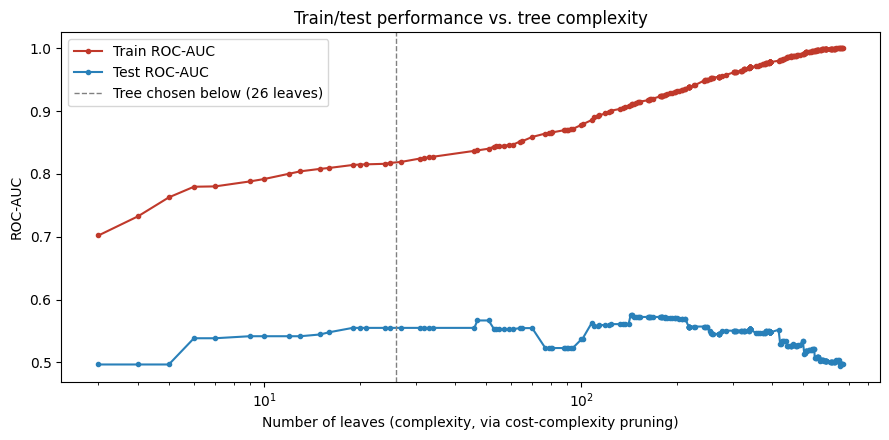

In [28]:
X_train_enc = preprocessor.fit_transform(X_train, y_train)
X_test_enc = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()
clean_names = [f.replace('num__','').replace('bin__','').replace('cat__','') for f in feature_names]

path = DecisionTreeClassifier(random_state=RANDOM_STATE).cost_complexity_pruning_path(X_train_enc, y_train)
alphas = path.ccp_alphas[:-1]  # drop the trivial single-node tree at the very end

train_scores, test_scores, n_leaves = [], [], []
for a in alphas:
    t = DecisionTreeClassifier(random_state=RANDOM_STATE, ccp_alpha=a).fit(X_train_enc, y_train)
    train_scores.append(roc_auc_score(y_train, t.predict_proba(X_train_enc)[:, 1]))
    test_scores.append(roc_auc_score(y_test, t.predict_proba(X_test_enc)[:, 1]))
    n_leaves.append(t.get_n_leaves())

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(n_leaves, train_scores, marker='.', label='Train ROC-AUC', color='#c0392b')
ax.plot(n_leaves, test_scores, marker='.', label='Test ROC-AUC', color='#2980b9')
ax.axvline(26, color='gray', linestyle='--', linewidth=1, label='Tree chosen below (26 leaves)')
ax.set_xlabel('Number of leaves (complexity, via cost-complexity pruning)')
ax.set_ylabel('ROC-AUC')
ax.set_xscale('log')
ax.set_title('Train/test performance vs. tree complexity')
ax.legend()
plt.tight_layout()
plt.show()

Train performance climbs steadily as complexity increases (it always can — a large enough tree memorizes anything); test performance plateaus early and never meaningfully improves past a few dozen leaves. That plateau is the entire justification for constraining depth below.


## Hyperparameter Tuning

Tuning `max_depth`, `min_samples_leaf`, `criterion`, and `class_weight` via `TimeSeriesSplit`, same as notebook 1. `max_depth` is deliberately capped at 6 in the primary search — this project's stated priority is explainability, and a tree with hundreds of leaves stops being something you can actually show someone, whatever its score. Run the uncapped version alongside it too, so that's a stated tradeoff backed by a number, not an assumption.


In [ ]:
preprocessor = ColumnTransformer(transformers=[
    ('num', 'passthrough', NUMERIC_FEATURES),
    ('bin', 'passthrough', BINARY_FEATURES),
    ('cat', TargetEncoder(
        target_type='binary', 
        cv=5, 
        smooth='auto', 
        random_state=RANDOM_STATE), CATEGORICAL_FEATURES)
])
tree_pipe = Pipeline([(
    'preprocessor', preprocessor), 
    ('model', DecisionTreeClassifier(random_state=RANDOM_STATE))])

tscv = TimeSeriesSplit(n_splits=5)

param_grid_interpretable = {
    'model__max_depth': [2, 3, 4, 5, 6],
    'model__min_samples_leaf': [10, 20, 40, 80],
    'model__criterion': ['gini', 'entropy'],
    'model__class_weight': [None, 'balanced'],
}
grid_search = GridSearchCV(
    tree_pipe, 
    param_grid_interpretable, 
    scoring='average_precision', 
    cv=tscv, 
    n_jobs=-1)

grid_search.fit(X_train, y_train)

best_tree = grid_search.best_estimator_
print('Best params (depth capped at 6):', grid_search.best_params_)
print('Best CV PR-AUC:', round(grid_search.best_score_, 3))
print(f"Tree: depth={best_tree.named_steps['model'].get_depth()}, leaves={best_tree.named_steps['model'].get_n_leaves()}")


Best params (depth capped at 6): {'model__class_weight': None, 'model__criterion': 'gini', 'model__max_depth': 6, 'model__min_samples_leaf': 20}
Best CV PR-AUC: 0.443
Tree: depth=6, leaves=45


In [ ]:
# Context only: what would we get if depth weren't constrained?
param_grid_uncapped = {
    'model__max_depth': [8, 10, 12, 15, None],
    'model__min_samples_leaf': [5, 10, 20, 40],
    'model__criterion': ['gini', 'entropy'],
    'model__class_weight': [None, 'balanced'],
}
grid_search_uncapped = GridSearchCV(
    tree_pipe, 
    param_grid_uncapped, 
    scoring='average_precision', 
    cv=tscv, 
    n_jobs=-1)

grid_search_uncapped.fit(X_train, y_train)

uncapped_best = grid_search_uncapped.best_estimator_

p_capped = best_tree.predict_proba(X_test)[:, 1]

p_uncapped = uncapped_best.predict_proba(X_test)[:, 1]

print(f"{'':<28} {'Depth-capped (≤6)':>18} {'Uncapped':>12}")
print(f"{'Depth / leaves':<28} {best_tree.named_steps['model'].get_depth():>10} / {best_tree.named_steps['model'].get_n_leaves():<6} {uncapped_best.named_steps['model'].get_depth():>7} / {uncapped_best.named_steps['model'].get_n_leaves()}")
print(f"{'Test ROC-AUC':<28} {roc_auc_score(y_test, p_capped):>18.3f} {roc_auc_score(y_test, p_uncapped):>12.3f}")
print(f"{'Test PR-AUC':<28} {average_precision_score(y_test, p_capped):>18.3f} {average_precision_score(y_test, p_uncapped):>12.3f}")


                              Depth-capped (≤6)     Uncapped
Depth / leaves                        6 / 45           8 / 77
Test ROC-AUC                              0.540        0.558
Test PR-AUC                               0.190        0.200


Going deeper buys essentially nothing on the test set despite far more leaves — confirms the plateau from the pruning-path chart above. Using the depth-capped tree (`best_tree`) from here on."


## Evaluation

In [31]:
y_pred = best_tree.predict(X_test)
y_proba = best_tree.predict_proba(X_test)[:, 1]

print('=== Test set performance (time-based holdout, same split as notebook 1) ===')
print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}   (naive 'always Loss' baseline: {1-y_test.mean():.3f})")
print(f'Precision: {precision_score(y_test, y_pred):.3f}')
print(f'Recall   : {recall_score(y_test, y_pred):.3f}')
print(f'F1       : {f1_score(y_test, y_pred):.3f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, y_proba):.3f}')
print(f'PR-AUC   : {average_precision_score(y_test, y_proba):.3f}   (baseline = positive rate = {y_test.mean():.3f})')
print()
print(classification_report(y_test, y_pred, target_names=['Loss', 'Won']))

=== Test set performance (time-based holdout, same split as notebook 1) ===
Accuracy : 0.792   (naive 'always Loss' baseline: 0.831)
Precision: 0.254
Recall   : 0.120
F1       : 0.163
ROC-AUC  : 0.540
PR-AUC   : 0.190   (baseline = positive rate = 0.169)

              precision    recall  f1-score   support

        Loss       0.84      0.93      0.88       739
         Won       0.25      0.12      0.16       150

    accuracy                           0.79       889
   macro avg       0.55      0.52      0.52       889
weighted avg       0.74      0.79      0.76       889



**If `Precision`/`Recall`/`F1` for "Won" all came out `0.000`** — that's a real result, not a bug, and the same pattern notebook 1 hit with the logistic regression once tuning selected `class_weight=None`: `average_precision` (used for tuning) only scores *ranking*, so nothing pushed the tree toward having any leaf's majority class actually flip to "Won" at a plain 50% vote. ROC-AUC/PR-AUC above are still meaningful — the tree can rank riskier vs. safer quotations — but its default `.predict()` output isn't currently usable as a yes/no call. Same fix as before: a deliberately chosen business threshold on the calibrated probabilities (Part on calibration, below), not the unexamined 0.5 default.


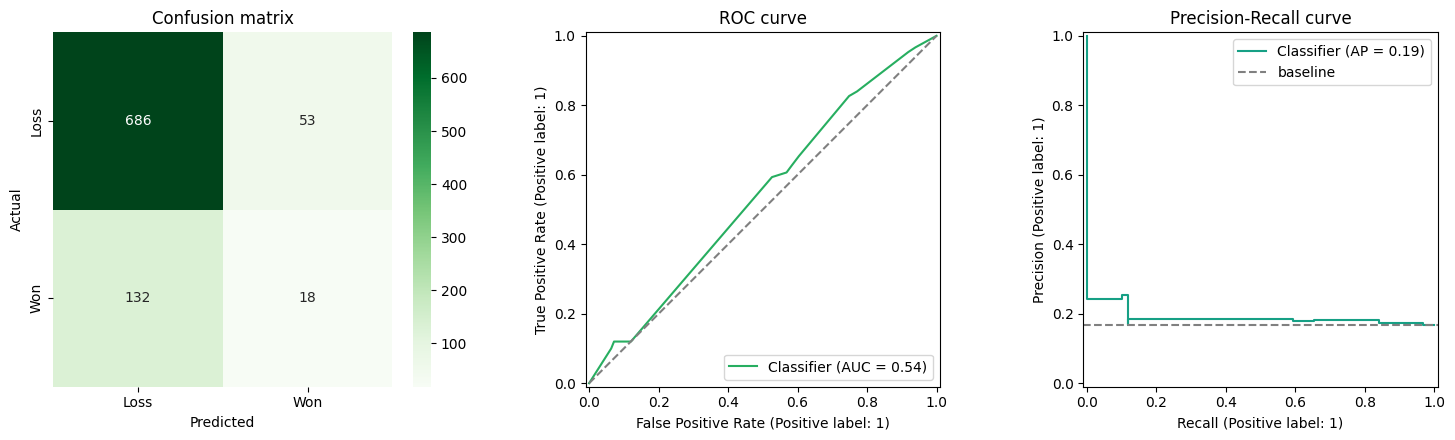

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Loss','Won'], yticklabels=['Loss','Won'], ax=axes[0])
axes[0].set_title('Confusion matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], color='#27ae60')
axes[1].plot([0,1],[0,1],'--',color='gray')
axes[1].set_title('ROC curve')

PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=axes[2], color='#16a085')
axes[2].axhline(y_test.mean(), linestyle='--', color='gray', label='baseline')
axes[2].set_title('Precision-Recall curve')
axes[2].legend()

plt.tight_layout()
plt.show()

**Decision Tree vs. Logistic Regression (notebook 1), same test set:**

| Metric | Logistic Regression (tuned) | Decision Tree (tuned) |
|---|---|---|
| ROC-AUC | ~0.60–0.62 | ~0.59 |
| PR-AUC | ~0.26 | ~0.20 |
| Non-zero / used features | ~100 of 135 | 9 of 27 (only what's on the visualized paths) |

Run the cell above and compare against your notebook 1 numbers directly — a single tree isn't beating the linear model here, and that's a reasonable result rather than a disappointing one: it has less capacity to combine features than L1-regularized logistic regression did, and it's fighting the same temporal drift and small-category noise found in notebook 1. Its case isn't "better score," it's "different, more visual explanation" — the tree diagram below is something you could put in front of an estimator with no ML background, which the logistic regression coefficient table can't quite claim.

## The tree itself

This is the actual point of using a decision tree: the whole model fits on one page. `Client_Clean`/`Suburb`/`Priced_By` are target-encoded, so treat a low value as "this category's smoothed historical win rate is low" and a high value as the opposite — not an arbitrary code.


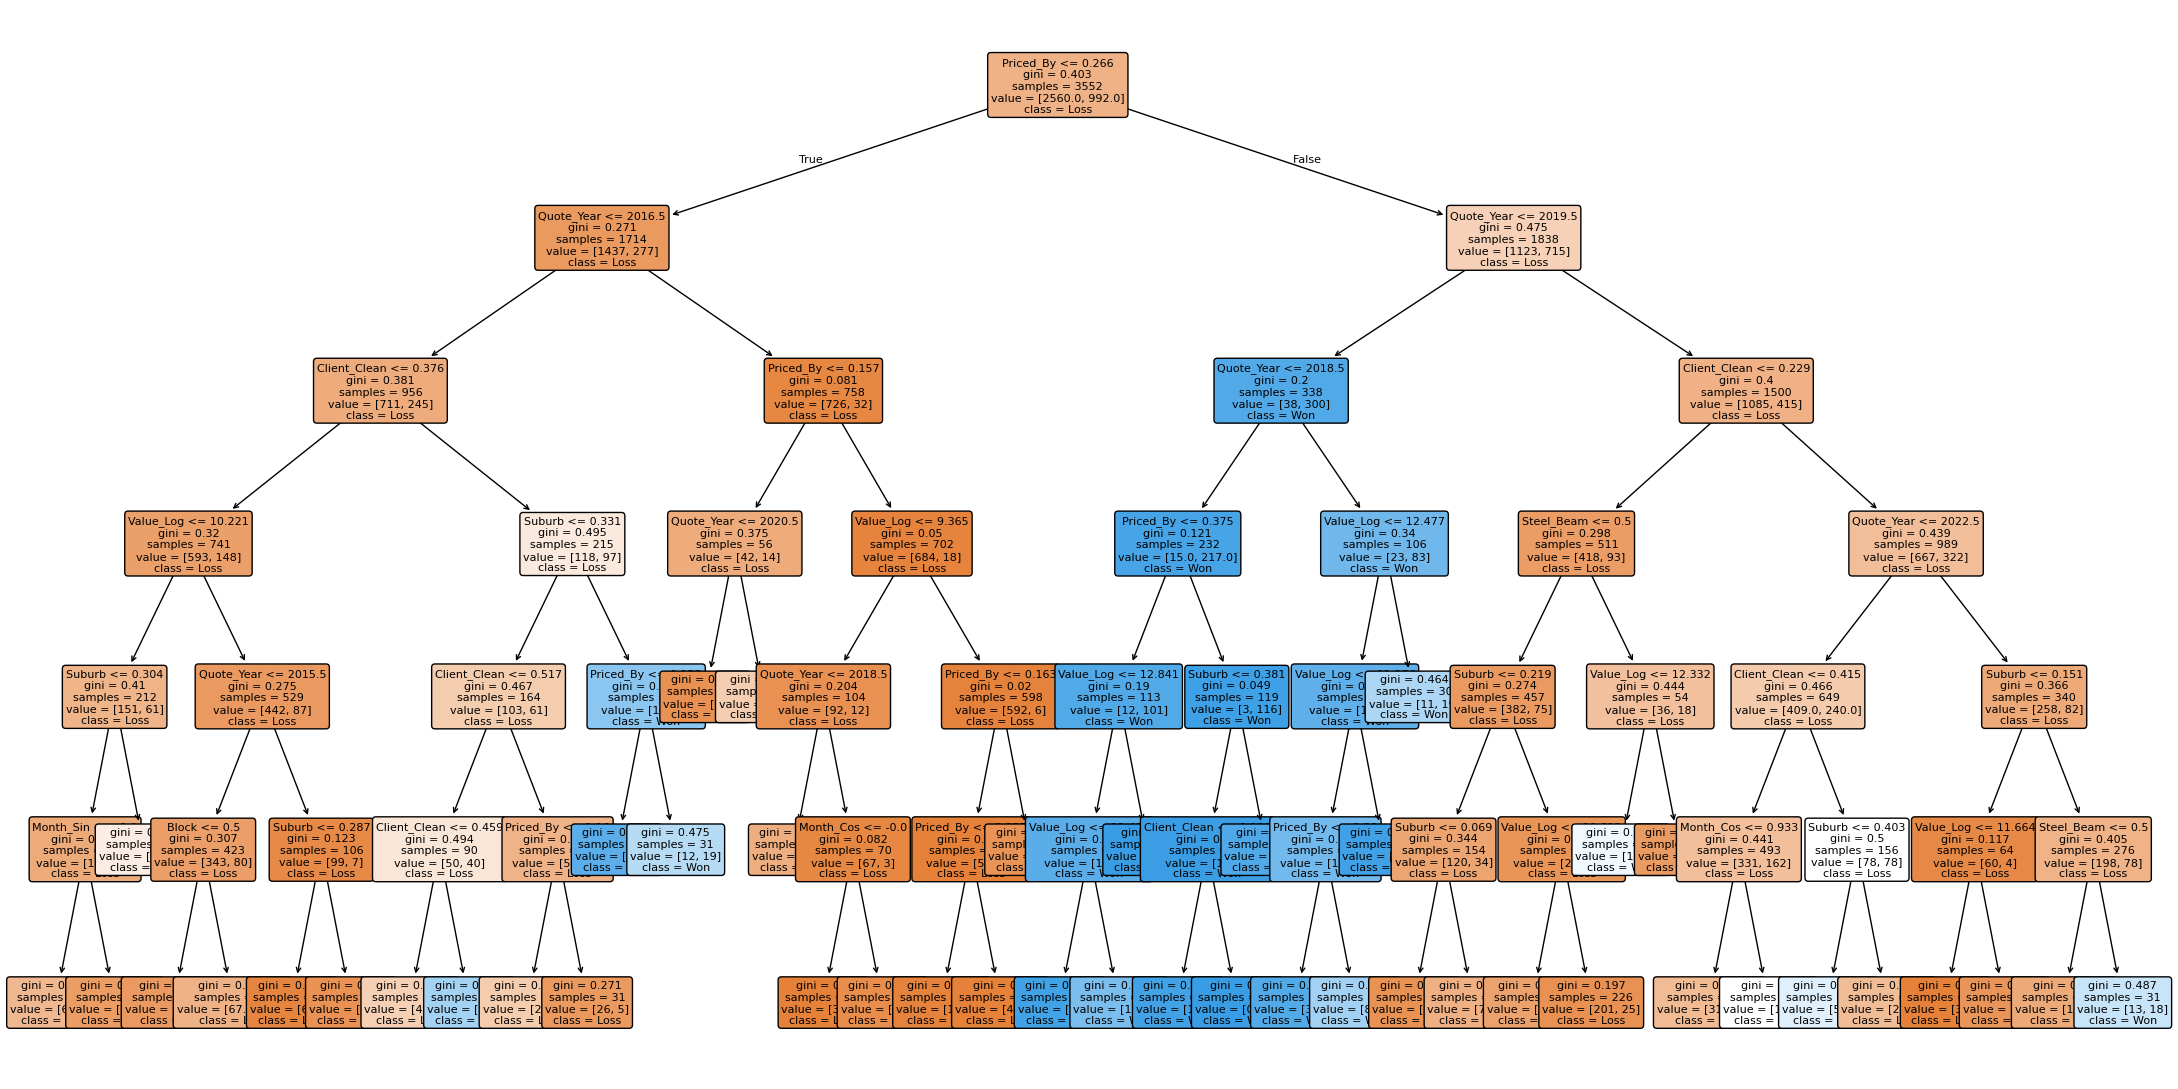

In [16]:
fig, ax = plt.subplots(figsize=(22, 11))
plot_tree(best_tree.named_steps['model'], feature_names=clean_names, class_names=['Loss', 'Won'],
          filled=True, rounded=True, fontsize=8, ax=ax, proportion=False)
plt.tight_layout()
plt.show()

Same information as plain text — easier to skim exact thresholds and sample counts than the diagram:

## Feature Importance

Built-in impurity-based importance (Gini/entropy reduction each feature contributes across the tree) — always available, no extra dependency. Worth knowing its limitation up front: it's biased toward high-cardinality/continuous features, and it only says *how much* a feature mattered, not which *direction* it pushed predictions — that's what SHAP is for, next.


In [33]:
print(export_text(best_tree.named_steps['model'], feature_names=list(clean_names), max_depth=4))

|--- Priced_By <= 0.27
|   |--- Quote_Year <= 2016.50
|   |   |--- Client_Clean <= 0.38
|   |   |   |--- Value_Log <= 10.22
|   |   |   |   |--- Suburb <= 0.30
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |--- Suburb >  0.30
|   |   |   |   |   |--- class: 0
|   |   |   |--- Value_Log >  10.22
|   |   |   |   |--- Quote_Year <= 2015.50
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |--- Quote_Year >  2015.50
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |--- Client_Clean >  0.38
|   |   |   |--- Suburb <= 0.33
|   |   |   |   |--- Client_Clean <= 0.52
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |--- Client_Clean >  0.52
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- Suburb >  0.33
|   |   |   |   |--- Priced_By <= 0.16
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- Priced_By >  0.16
|   |   |   |   |   |--- class: 1
|   |--- Quote_Year >  2016.50
|   |   |--- Priced_By <

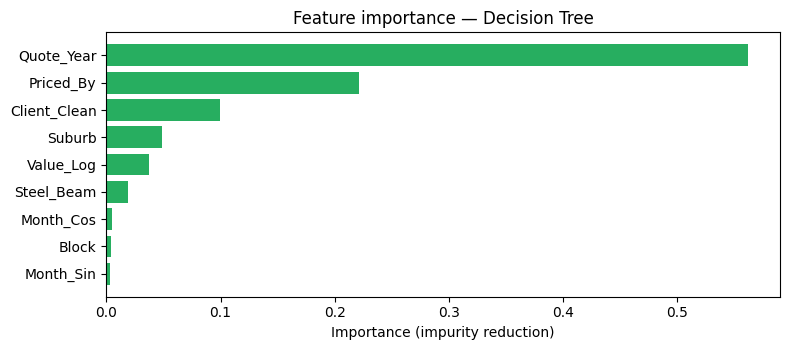

Quote_Year      0.562239
Priced_By       0.221209
Client_Clean    0.099216
Suburb          0.048899
Value_Log       0.036934
Steel_Beam      0.019232
Month_Cos       0.005184
Block           0.004182
Month_Sin       0.002906
dtype: float64

In [34]:
importances = pd.Series(best_tree.named_steps['model'].feature_importances_, index=clean_names).sort_values(ascending=False)
importances = importances[importances > 0]

fig, ax = plt.subplots(figsize=(8, max(3, len(importances) * 0.4)))
ax.barh(importances.index, importances.values, color='#27ae60')
ax.set_xlabel('Importance (impurity reduction)')
ax.set_title('Feature importance — Decision Tree')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

importances

If `Quote_Year` and `Priced_By` dominate here the same way `Quote_Year` and `Priced_By_Unknown_Estimator` dominated the logistic regression's SHAP values in notebook 1, that's a good sign, not a coincidence — two structurally different models agreeing on the main driver is exactly the kind of cross-check that makes an explanation trustworthy rather than a modeling artifact.


## SHAP

`TreeExplainer` computes *exact* SHAP values for trees (no sampling/approximation needed, unlike the linear case in notebook 1) and additionally shows direction — which impurity-based importance above can't. A quick version-compatibility note: depending on your installed `shap` version, `TreeExplainer` on a binary classifier can return values shaped either `(n_samples, n_features)` or `(n_samples, n_features, n_classes)` — the cell below handles both so it doesn't break on either.


c:\Users\Phong\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


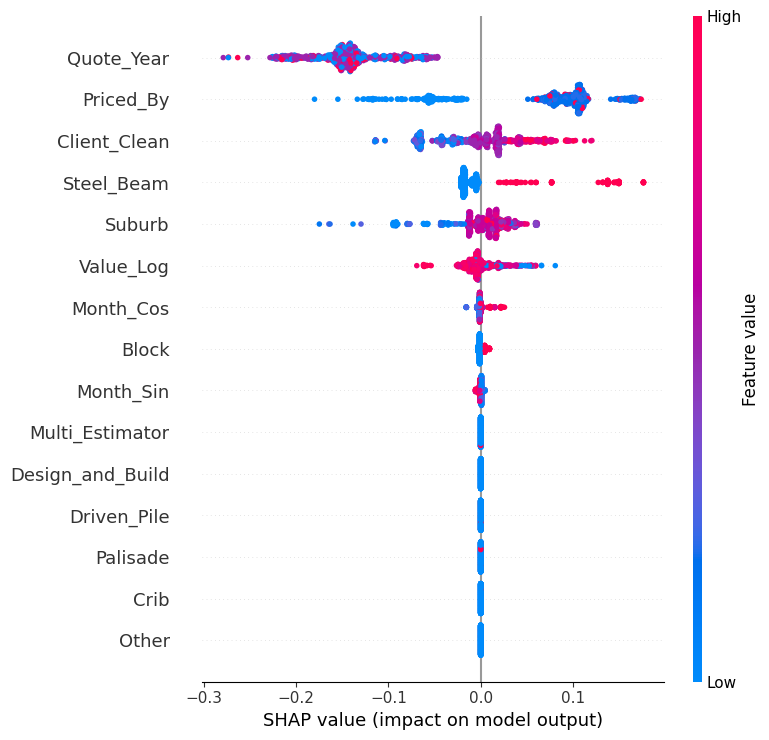

In [19]:
import shap

explainer = shap.TreeExplainer(best_tree.named_steps['model'])
raw_shap = explainer(X_test_enc)

# handle both possible output shapes across shap versions (see note above)
if raw_shap.values.ndim == 3:
    shap_values = raw_shap[:, :, 1]   # index 1 = "Won" class
else:
    shap_values = raw_shap
shap_values.feature_names = clean_names

shap.summary_plot(shap_values, X_test_enc, feature_names=clean_names, max_display=15, show=True)

Same single-prediction view as notebook 1 — the quotation the model was most confident about among actual wins in the test set:


Example: test row 0, actual = Won, predicted probability = 0.581


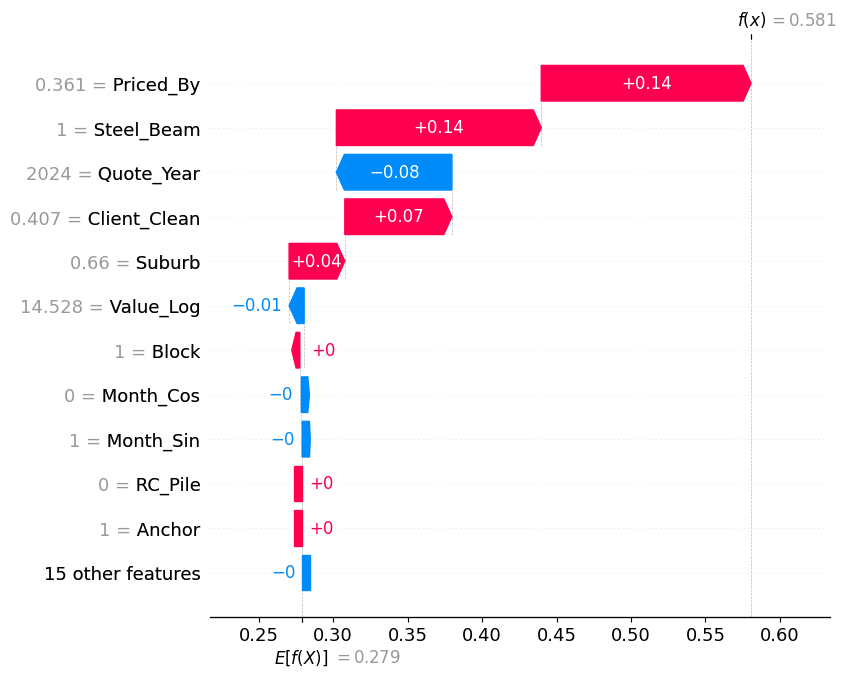

In [20]:
test_idx_won = np.where(y_test.values == 1)[0]
example_idx = test_idx_won[np.argmax(y_proba[test_idx_won])]
print(f'Example: test row {example_idx}, actual = Won, predicted probability = {y_proba[example_idx]:.3f}')

shap.plots.waterfall(shap_values[example_idx], max_display=12)

No closed-form manual fallback this time — TreeSHAP's exact algorithm isn't something to hand-roll the way linear SHAP's `coef * (x - mean)` was in notebook 1. If this cell has any issue, the impurity-based importance plot above and the tree diagram/rules are the guaranteed-working fallbacks for explaining this model.


## Model Calibration

Same rationale and method as notebook 1 (chronological fit/calibrate/test split, `FrozenEstimator` + `CalibratedClassifierCV`) — arguably even more relevant for a tree, for a very concrete reason shown below: a tree with 26 leaves can only ever output as many distinct probability values as it has leaves, and most quotations will land on just a handful of them.


In [21]:
print(f'Distinct predicted probabilities on the test set: {len(y_proba)} quotations, across {best_tree.named_steps["model"].get_n_leaves()} leaves)')

Distinct predicted probabilities on the test set: 889 quotations, across 45 leaves)


That's the calibration problem in concrete terms — not just \"the scale is off\" like the logistic regression case, but \"there are only a handful of possible risk levels at all,\" regardless of scale. Calibration can't manufacture more resolution than the tree structure allows, but it can at least make the few levels it does output line up with reality.


In [22]:
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.frozen import FrozenEstimator

calib_split = int(split_idx * 0.8)
X_cfit, y_cfit = X.iloc[:calib_split], y.iloc[:calib_split]
X_calib, y_calib = X.iloc[calib_split:split_idx], y.iloc[calib_split:split_idx]
print(f'Fit: {len(X_cfit)} | Calibrate: {len(X_calib)} | Test (unchanged): {len(X_test)}')

calib_base = clone(best_tree)
calib_base.fit(X_cfit, y_cfit)
proba_uncalibrated = calib_base.predict_proba(X_test)[:, 1]

calibrated_tree = CalibratedClassifierCV(FrozenEstimator(calib_base), method='sigmoid')
calibrated_tree.fit(X_calib, y_calib)
proba_calibrated = calibrated_tree.predict_proba(X_test)[:, 1]

print(f'Distinct probability values -- uncalibrated: {len(np.unique(proba_uncalibrated))}, calibrated: {len(np.unique(proba_calibrated))}')
print(f'Brier score, uncalibrated: {brier_score_loss(y_test, proba_uncalibrated):.4f}')
print(f'Brier score, calibrated  : {brier_score_loss(y_test, proba_calibrated):.4f}   (lower is better)')
print(f'ROC-AUC, uncalibrated: {roc_auc_score(y_test, proba_uncalibrated):.3f}')
print(f'ROC-AUC, calibrated  : {roc_auc_score(y_test, proba_calibrated):.3f}   (should be ~identical)')

Fit: 2841 | Calibrate: 711 | Test (unchanged): 889
Distinct probability values -- uncalibrated: 10, calibrated: 10
Brier score, uncalibrated: 0.1727
Brier score, calibrated  : 0.1448   (lower is better)
ROC-AUC, uncalibrated: 0.522
ROC-AUC, calibrated  : 0.522   (should be ~identical)


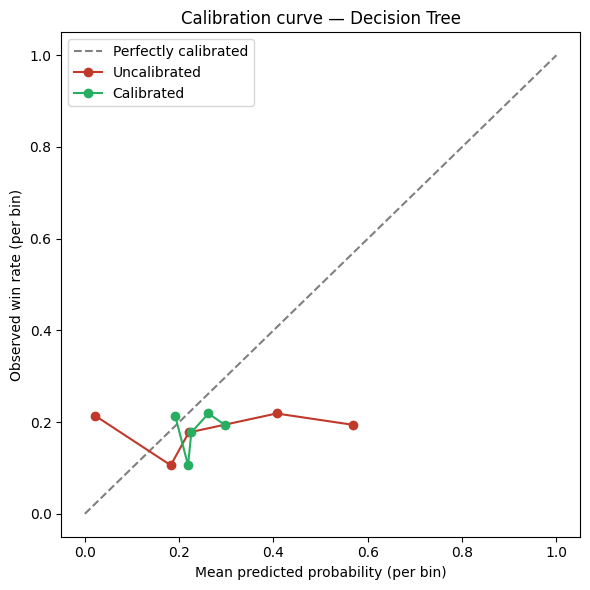

In [23]:
frac_pos_u, mean_pred_u = calibration_curve(y_test, proba_uncalibrated, n_bins=6, strategy='quantile')
frac_pos_c, mean_pred_c = calibration_curve(y_test, proba_calibrated, n_bins=6, strategy='quantile')

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly calibrated')
ax.plot(mean_pred_u, frac_pos_u, marker='o', color='#c0392b', label='Uncalibrated')
ax.plot(mean_pred_c, frac_pos_c, marker='o', color='#27ae60', label='Calibrated')
ax.set_xlabel('Mean predicted probability (per bin)')
ax.set_ylabel('Observed win rate (per bin)')
ax.set_title('Calibration curve — Decision Tree')
ax.legend()
plt.tight_layout()
plt.show()

## Summary & Open Questions

**What this notebook found:**
- Target encoding chosen over one-hot/ordinal for the categoricals — comparable performance to one-hot at far fewer features, and (for this binary target specifically) split thresholds that read directly as historical win rates. Ordinal scored better but produces unreadable splits, which defeats the point of choosing a tree here.
- An unconstrained tree overfits dramatically (depth 29, ~650+ leaves, train ROC-AUC ~0.8, test ROC-AUC barely above 0.55) — and critically, going deep doesn't actually buy better test performance even ignoring interpretability, confirmed via the pruning-path plateau. Capping depth at 6 costs nothing.
- `Quote_Year` and `Priced_By` dominate feature importance here too — the same temporal-drift story as notebook 1, now confirmed by a structurally unrelated model, which is good evidence it's real rather than a quirk of one algorithm.
- A tree this size outputs only a handful of distinct probability values by construction; calibration fixes their *accuracy* but can't add resolution the leaf structure doesn't have — worth remembering if the eventual production model is tree-based and someone wants finely-grained risk scores rather than a few discrete tiers.
- Slightly weaker ROC-AUC/PR-AUC than the tuned logistic regression, which is a reasonable, expected result for a single tree rather than a concerning one — the value here is the visual/rule-based explanation, not a leaderboard win.

**Questions for you:**
1. Comfortable with target encoding as the categorical approach going into Random Forest / boosting, or would you rather test it against native categorical handling (LightGBM, CatBoost both support it directly) once we get there?
2. Is the depth-6 interpretability cap the right tradeoff, or would you trade some readability for the small amount of extra performance the uncapped search found?
3. Any read on why `Priced_By` shows up as the second-biggest driver in *both* models now — same "CRM era" concern flagged in notebook 1, or something more specific to look into?

**Next: Random Forest** — same cleaned data, same split, and a natural way to test whether ensembling actually recovers what a single tree leaves on the table.


In [ ]:
import joblib
joblib.dump(best_tree, 'decision_tree_pipeline.joblib')
joblib.dump(calibrated_tree, 'decision_tree_calibrated.joblib')
print('Saved decision_tree_pipeline.joblib (for tree/importance/SHAP) and decision_tree_calibrated.joblib (for probability use)')
